In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ==========================================
# 0. ENVIRONMENT SETUP
# ==========================================
!pip install -q huggingface_hub tabpfn skrebate mrmr_selection imbalanced-learn xgboost shap statsmodels

import os
import re
import numpy as np
import pandas as pd
from datetime import datetime

# Define Project Paths
BASE_DIR = "/content/drive/MyDrive/Lung_Cancer_Project"
EXPR_PATH = f"{BASE_DIR}/LUAD/data_mrna_seq_v2_rsem.txt"
CLIN_PATH = f"{BASE_DIR}/LUAD/data_clinical_patient.txt"

# Dynamic Experiment Directory
EXP_NAME = "LUAD_Optimized_Ensemble_" + datetime.now().strftime("%Y%m%d_%H%M")
EXP_DIR = os.path.join(BASE_DIR, "experiments", EXP_NAME)

METRIC_DIR = os.path.join(EXP_DIR, "metrics")
PLOT_DIR = os.path.join(EXP_DIR, "plots")
BIOMARKER_DIR = os.path.join(EXP_DIR, "biomarkers")

os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(BIOMARKER_DIR, exist_ok=True)

print(f"✅ Environment Ready. Results will save to: {EXP_DIR}")

✅ Environment Ready. Results will save to: /content/drive/MyDrive/Lung_Cancer_Project/experiments/LUAD_Optimized_Ensemble_20260318_1534


In [3]:
!hf auth login

User is already logged in.


In [4]:
# ==========================================================
# TCGA RNA-SEQ PREPROCESSING PIPELINE
# Early vs Late Stage Lung Cancer Classification
# ==========================================================

import pandas as pd
import numpy as np
import re

def preprocess_tcga_lusc(expr_path, clin_path):
    """
    Complete preprocessing pipeline for TCGA RNA-seq and clinical data.
    Prepares the dataset for machine learning classification.
    """

    # ----------------------------------------------------------
    # 1. Load Data
    # ----------------------------------------------------------
    print("Loading datasets...")
    expr_df = pd.read_csv(expr_path, sep="\t", comment="#", low_memory=False)
    clin_df = pd.read_csv(clin_path, sep="\t", comment="#")

    print(f"Raw Expression shape: {expr_df.shape}")
    print(f"Raw Clinical shape: {clin_df.shape}")

    # ----------------------------------------------------------
    # 2. Expression Matrix Cleaning
    # ----------------------------------------------------------
    # Remove rows without a gene symbol
    expr_df = expr_df.dropna(subset=["Hugo_Symbol"])

    # Drop Entrez_Gene_Id to keep only Hugo_Symbol
    if "Entrez_Gene_Id" in expr_df.columns:
        expr_df = expr_df.drop(columns=["Entrez_Gene_Id"])

    # Set Hugo_Symbol as the index
    expr_df = expr_df.set_index("Hugo_Symbol")

    # Handle duplicated genes by averaging their expression values
    expr_df = expr_df.groupby(expr_df.index).mean()

    # Transpose matrix -> Samples (rows) × Genes (columns)
    expr_df = expr_df.T

    # ----------------------------------------------------------
    # 3. Fix TCGA Sample IDs
    # ----------------------------------------------------------
    # Trim expression sample IDs to the first 12 characters (e.g., TCGA-XX-XXXX)
    expr_df.index = expr_df.index.str[:12]

    # Remove duplicate patients (keeping the first occurrence)
    expr_df = expr_df[~expr_df.index.duplicated(keep="first")]

    print(f"Expression matrix after cleaning: {expr_df.shape}")

    # ----------------------------------------------------------
    # 4. Clinical Data Processing
    # ----------------------------------------------------------
    # Keep only necessary columns
    clin_df = clin_df[["PATIENT_ID", "AJCC_PATHOLOGIC_TUMOR_STAGE"]].copy()

    # Remove missing stages
    clin_df = clin_df.dropna(subset=["AJCC_PATHOLOGIC_TUMOR_STAGE"])

    # Clean stage labels (uppercase, strip whitespace)
    clin_df["AJCC_PATHOLOGIC_TUMOR_STAGE"] = clin_df["AJCC_PATHOLOGIC_TUMOR_STAGE"].astype(str).str.upper().str.strip()

    # Ensure clinical IDs match the 12-character format
    clin_df["PATIENT_ID"] = clin_df["PATIENT_ID"].str[:12]

    # ----------------------------------------------------------
    # 5. Merge Expression and Clinical Data
    # ----------------------------------------------------------
    # Merge using inner join to retain only patients present in both datasets
    merged_df = expr_df.merge(clin_df, left_index=True, right_on="PATIENT_ID", how="inner")

    print(f"Merged dataset shape: {merged_df.shape}")

    # ----------------------------------------------------------
    # 6. Robust Stage Mapping
    # ----------------------------------------------------------
    def map_stage_regex(stage_str):
        """
        Extracts Roman numeral stages ignoring extra text (e.g., 'STAGE IIIA (AJCC V6)').
        Early stage (I, II) -> 0
        Late stage (III, IV) -> 1
        """
        # Regex looks for "STAGE " followed by I, II, III, or IV
        match = re.search(r"STAGE\s+(IV|III|II|I)[A-C]*", stage_str)
        if not match:
            return None

        base_stage = match.group(1)
        if base_stage in ["I", "II"]:
            return 0  # Early
        elif base_stage in ["III", "IV"]:
            return 1  # Late
        return None

    # Apply mapping and drop ambiguous/unmapped samples
    merged_df["target"] = merged_df["AJCC_PATHOLOGIC_TUMOR_STAGE"].apply(map_stage_regex)
    merged_df = merged_df.dropna(subset=["target"])
    merged_df["target"] = merged_df["target"].astype(int)

    # ----------------------------------------------------------
    # 7. Final Dataset Creation
    # ----------------------------------------------------------
    y = merged_df["target"].values
    X = merged_df.drop(columns=["PATIENT_ID", "AJCC_PATHOLOGIC_TUMOR_STAGE", "target"])

    # ----------------------------------------------------------
    # 8. Dataset Validation
    # ----------------------------------------------------------
    print("\n======================================")
    print("DATASET SUMMARY")
    print("======================================")
    print(f"Samples: {X.shape[0]}")
    print(f"Genes: {X.shape[1]}")

    unique, counts = np.unique(y, return_counts=True)
    print("\nClass distribution:")
    for val, count in zip(unique, counts):
        label = "Early stage (0)" if val == 0 else "Late stage (1)"
        print(f"{label}: {count}")

    print(f"\nMissing values in X: {X.isna().sum().sum()}")
    print(f"Duplicate samples in X: {X.index.duplicated().sum()}")
    # ----------------------------------------------------------
    # 9. RNA-seq Filtering (Ordered)
    # ----------------------------------------------------------
    print("\n======================================")
    print("RUNNING RNA-SEQ FILTERING")
    print("======================================")

    # A. Expression filtering: Keep genes expressed >1 in at least 10 samples
    mask = (X > 1).sum(axis=0) >= 10
    X = X.loc[:, mask]
    print(f"After Expression Filtering: {X.shape[1]} genes remain")

    # B. Log transformation: log2(X + 1) to stabilize variance
    X = np.log2(X + 1)
    print("Log2 Transformation applied.")

    # C. Variance filtering: Remove genes with zero variance
    #var = X.var()
    #X = X.loc[:, var > 0]
    #print(f"After Variance Filtering: {X.shape[1]} genes remain")

    print("\n======================================")
    print("FINAL FILTERED DATASET")
    print("======================================")
    print(f"Samples: {X.shape[0]}")
    print(f"Genes: {X.shape[1]}")
    # ----------------------------------------------------------


    # ----------------------------------------------------------
    # 10. Final Output
    # ----------------------------------------------------------
    return X, y, merged_df

# ==========================================================
# EXECUTION & VERIFICATION
# ==========================================================
# Your exact Google Drive paths
BASE_DIR = "/content/drive/MyDrive/Lung_Cancer_Project"
expr_path = f"{BASE_DIR}/LUAD/data_mrna_seq_v2_rsem.txt"
clin_path = f"{BASE_DIR}/LUAD/data_clinical_patient.txt"

# Run the pipeline
X, y, final_df = preprocess_tcga_lusc(expr_path, clin_path)

# ----------------------------------------------------------
# VERIFICATION CHECKS (Confirms Data is ML-Ready)
# ----------------------------------------------------------
print("\n======================================")
print("FINAL ML READINESS VERIFICATION")
print("======================================")
print(f"✅ Labels mapped correctly: {np.unique(y)} (Expected: [0, 1])")
print(f"✅ X matrix is entirely numeric: {np.issubdtype(X.values.dtype, np.number)}")
print("\n🔍 Preview of X (First 3 patients, 4 genes) - Should be log2 scaled values:")
print(X.iloc[:3, :4])

Loading datasets...
Raw Expression shape: (20531, 512)
Raw Clinical shape: (566, 38)
Expression matrix after cleaning: (510, 20511)
Merged dataset shape: (508, 20513)

DATASET SUMMARY
Samples: 508
Genes: 20511

Class distribution:
Early stage (0): 398
Late stage (1): 110

Missing values in X: 0
Duplicate samples in X: 0

RUNNING RNA-SEQ FILTERING
After Expression Filtering: 19188 genes remain
Log2 Transformation applied.

FINAL FILTERED DATASET
Samples: 508
Genes: 19188

FINAL ML READINESS VERIFICATION
✅ Labels mapped correctly: [0 1] (Expected: [0, 1])
✅ X matrix is entirely numeric: True

🔍 Preview of X (First 3 patients, 4 genes) - Should be log2 scaled values:
       A1BG      A1CF     A2BP1     A2LD1
0  4.756500  0.000000  1.457016  7.092778
1  6.920472  0.402722  1.383939  6.492861
2  5.696542  0.000000  0.000000  7.249189


In [5]:
!pip install statsmodels

In [6]:
# ==========================================
# STEP 4: FINAL RESEARCH-GRADE PIPELINE (BULLETPROOF)
# ==========================================

import os
import gc
import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# NOTE: Make sure statsmodels is installed: !pip install statsmodels
from statsmodels.stats.multitest import fdrcorrection

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from skrebate import ReliefF
from mrmr import mrmr_classif

from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

# ===============================
# CREATE SAFE EXPERIMENT FOLDER
# ===============================
BASE_DIR = "/content/drive/MyDrive/Lung_Cancer_Project"

EXP_NAME = "FINAL_SAFE_" + datetime.now().strftime("%Y%m%d_%H%M")
EXP_DIR = os.path.join(BASE_DIR, "experiments", EXP_NAME)

METRIC_DIR = os.path.join(EXP_DIR, "metrics")
PLOT_DIR = os.path.join(EXP_DIR, "plots")
BIOMARKER_DIR = os.path.join(EXP_DIR, "biomarkers") # Added to save genes mid-run

os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(BIOMARKER_DIR, exist_ok=True)

print("✅ Safe Experiment Directory:", EXP_DIR)

# ===============================
# CNN MODEL
# ===============================
def build_cnn(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(16, 3, activation="relu",
                               kernel_regularizer=tf.keras.regularizers.l2(0.02),
                               input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(0.02)),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ===============================
# SETTINGS
# ===============================
CLINICAL_THRESHOLD = 0.30   # Slightly adjusted for minority class sensitivity
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = "cuda" if torch.cuda.is_available() else "cpu"

fold_results = []

print("🚀 Starting Clinical Pipeline with OOM Protection...")

# ===============================
# CROSS VALIDATION LOOP
# ===============================
# Assuming X and y are already defined from Step 3
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    print(f"\n{'='*40}\n===== FOLD {fold}/5 =====\n{'='*40}")

    # SPLIT
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ===============================
    # 1. SCALING
    # ===============================
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

    # ===============================
    # 2. SMOTE (FIXED LEAKAGE: Applied BEFORE Feature Selection)
    # ===============================
    print("Applying SMOTETomek to balance training classes...")
    smt = SMOTETomek(random_state=42)
    X_train_bal, y_train_bal = smt.fit_resample(X_train_scaled, y_train)

    # ===============================
    # 3. HYBRID FEATURE SELECTION (FDR + Dynamic Memory)
    # ===============================

    # A. ANOVA with FDR Correction
    print("Running ANOVA (FDR Corrected)...")
    f_stats, p_values = f_classif(X_train_bal, y_train_bal)

    # Apply Benjamini-Hochberg FDR (alpha=0.01)
    rejected_null, adj_p_values = fdrcorrection(p_values, alpha=0.01, method='indep')
    anova_genes = X_train_bal.columns[rejected_null]

    # Failsafe: If FDR passes too many genes (>3000), force top 3000 by p-value to save RAM
    if len(anova_genes) > 3000:
        top_indices = np.argsort(p_values)[:3000]
        anova_genes = X_train_bal.columns[top_indices]
    # Failsafe: If FDR is too strict (<150), force top 150 to keep pipeline running
    elif len(anova_genes) < 150:
        top_indices = np.argsort(p_values)[:150]
        anova_genes = X_train_bal.columns[top_indices]

    print(f"Genes passed to ReliefF: {len(anova_genes)}")

    X_train_fs1 = X_train_bal[anova_genes]

    # B. ReliefF (Reduces to 1000)
    print("Running ReliefF...")
    relief_target = min(1000, len(anova_genes))
    relief = ReliefF(n_features_to_select=relief_target, n_neighbors=100)
    relief.fit(X_train_fs1.values, y_train_bal)

    relief_genes = anova_genes[np.argsort(relief.feature_importances_)[::-1][:relief_target]]
    X_train_fs2 = X_train_fs1[relief_genes]

    del relief # Free massive distance matrix
    gc.collect()

    # C. mRMR (Reduces to 500)
    print("Running mRMR...")
    mrmr_target = min(500, len(relief_genes))
    mrmr_genes = mrmr_classif(X=X_train_fs2, y=pd.Series(y_train_bal), K=mrmr_target)
    X_train_fs3 = X_train_fs2[mrmr_genes]

    gc.collect()

    # D. Random Forest (Reduces to Final 150)
    print("Running Random Forest final selection...")
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
    rf.fit(X_train_fs3, y_train_bal)

    final_genes = pd.Series(
        rf.feature_importances_,
        index=X_train_fs3.columns
    ).sort_values(ascending=False).head(150).index

    print(f"🎯 Final Feature Count: {len(final_genes)}")

    # Save genes to Drive immediately in case of crash
    pd.DataFrame(final_genes, columns=["Gene"]).to_csv(f"{BIOMARKER_DIR}/fold_{fold}_genes.csv", index=False)

    # Apply final genes to Train and Val sets
    X_train_final = X_train_bal[final_genes]
    X_val_final = X_val_scaled[final_genes]

    # ===============================
    # 4. MODEL TRAINING
    # ===============================

    # --- CNN ---
    print("Training CNN...")
    X_train_cnn = np.expand_dims(X_train_final.values, axis=2)
    X_val_cnn = np.expand_dims(X_val_final.values, axis=2)

    cnn = build_cnn((X_train_cnn.shape[1], 1))
    early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

    cnn.fit(X_train_cnn, y_train_bal, validation_data=(X_val_cnn, y_val),
            epochs=50, batch_size=32, callbacks=[early_stop],
            class_weight={0:1.0, 1:2.0}, verbose=0)
    cnn_probs = cnn.predict(X_val_cnn, verbose=0).flatten()

    # --- XGBoost ---
    print("Training XGBoost...")
    xgb = XGBClassifier(max_depth=5, learning_rate=0.05, n_estimators=400,
                        scale_pos_weight=2.0, eval_metric="logloss", random_state=42)
    xgb.fit(X_train_final, y_train_bal)
    xgb_probs = xgb.predict_proba(X_val_final)[:,1]

    # --- TabPFN ---
    print("Training TabPFN...")
    tab = TabPFNClassifier(device=device)

    # THIS IS THE LINE THAT WAS MISSING!
    # The corrected line without .values
    tab.fit(X_train_final.values.astype(np.float32), y_train_bal)

    # Batch prediction to prevent TabPFN OOM
    print("Predicting with TabPFN in batches...")
    tab_probs = []
    batch_size = 100
    val_array = X_val_final.values.astype(np.float32)
    for i in range(0, len(val_array), batch_size):
        batch = val_array[i:i+batch_size]
        preds = tab.predict_proba(batch)[:, 1]
        tab_probs.extend(preds)
    tab_probs = np.array(tab_probs)


    # ===============================
    # 5. ENSEMBLE FUSION
    # ===============================
    ens_probs = (0.2 * cnn_probs) + (0.3 * xgb_probs) + (0.5 * tab_probs)
    ens_preds = (ens_probs > CLINICAL_THRESHOLD).astype(int)

    # ===============================
    # 6. METRICS & CHECKPOINTING
    # ===============================
    acc = accuracy_score(y_val, ens_preds)
    prec = precision_score(y_val, ens_preds, zero_division=0)
    rec = recall_score(y_val, ens_preds, zero_division=0)
    f1 = f1_score(y_val, ens_preds, zero_division=0)
    auc = roc_auc_score(y_val, ens_probs)

    fold_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    })

    # SAVE METRICS IMMEDIATELY
    pd.DataFrame(fold_results).to_csv(f"{METRIC_DIR}/fold_metrics.csv", index=False)
    print(f"Fold {fold} Metrics Saved | Recall: {rec:.3f} | AUC: {auc:.3f}")

    # ===============================
    # 7. AGGRESSIVE MEMORY SWEEP
    # ===============================
    print("Sweeping memory for next fold...")
    del cnn, xgb, tab, rf
    del X_train_scaled, X_train_bal, X_train_fs1, X_train_fs2, X_train_fs3, X_train_final
    del X_val_scaled, X_val_final

    gc.collect()
    tf.keras.backend.clear_session()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ===============================
# FINAL RESULTS
# ===============================
results = pd.DataFrame(fold_results)
results.to_csv(f"{METRIC_DIR}/final_results.csv", index=False)

print("\n" + "="*40)
print("🏆 PIPELINE COMPLETE. FINAL AVERAGE RESULTS:")
print("="*40)
print(results.mean())

✅ Safe Experiment Directory: /content/drive/MyDrive/Lung_Cancer_Project/experiments/FINAL_SAFE_20260318_1536
🚀 Starting Clinical Pipeline with OOM Protection...

===== FOLD 1/5 =====
Applying SMOTETomek to balance training classes...
Running ANOVA (FDR Corrected)...
Genes passed to ReliefF: 2913
Running ReliefF...
Running mRMR...


100%|██████████| 500/500 [02:37<00:00,  3.18it/s]


Running Random Forest final selection...
🎯 Final Feature Count: 150
Training CNN...
Training XGBoost...
Training TabPFN...


tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Training XGBoost...
Training TabPFN...
Predicting with TabPFN in batches...
Fold 3 Metrics Saved | Recall: 0.136 | AUC: 0.586
Sweeping memory for next fold...

===== FOLD 4/5 =====
Applying SMOTETomek to balance training classes...
Running ANOVA (FDR Corrected)...
Genes passed to ReliefF: 3000
Running ReliefF...
Running mRMR...


100%|██████████| 500/500 [02:44<00:00,  3.04it/s]


Running Random Forest final selection...
🎯 Final Feature Count: 150
Training CNN...
Training XGBoost...
Training TabPFN...
Predicting with TabPFN in batches...
Fold 4 Metrics Saved | Recall: 0.182 | AUC: 0.556
Sweeping memory for next fold...

===== FOLD 5/5 =====
Applying SMOTETomek to balance training classes...
Running ANOVA (FDR Corrected)...
Genes passed to ReliefF: 1917
Running ReliefF...
Running mRMR...


100%|██████████| 500/500 [02:37<00:00,  3.18it/s]


Running Random Forest final selection...
🎯 Final Feature Count: 150
Training CNN...
Training XGBoost...
Training TabPFN...
Predicting with TabPFN in batches...
Fold 5 Metrics Saved | Recall: 0.500 | AUC: 0.689
Sweeping memory for next fold...

🏆 PIPELINE COMPLETE. FINAL AVERAGE RESULTS:
fold         3.000000
accuracy     0.716599
precision    0.303542
recall       0.245455
f1           0.270631
auc          0.582884
dtype: float64


Loading saved data and initializing visualizations...
Generating PCA Plots...


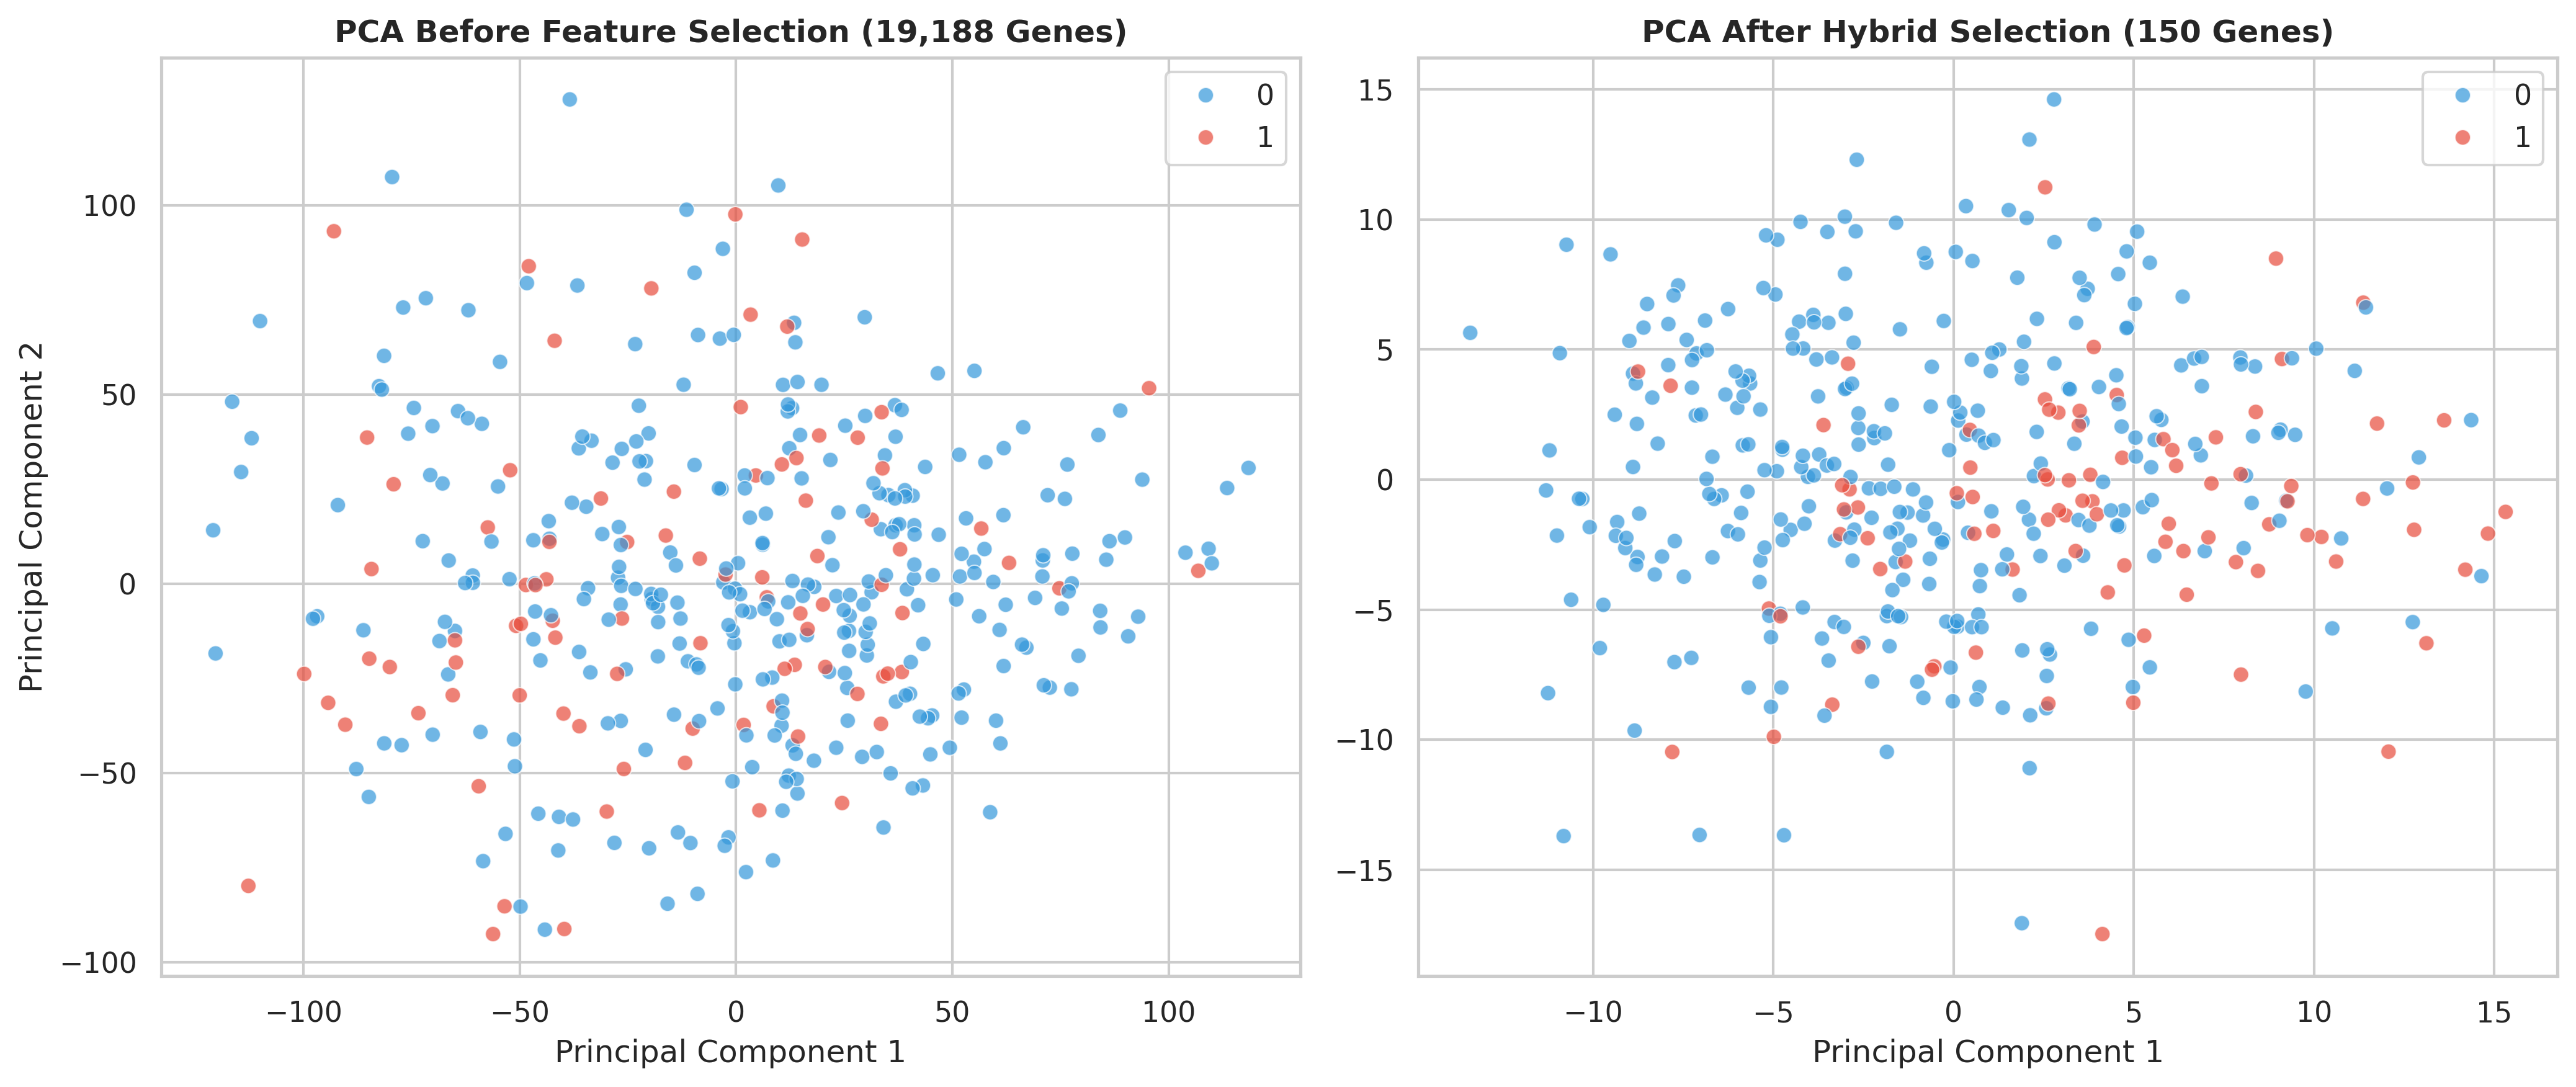

Generating Heatmap...


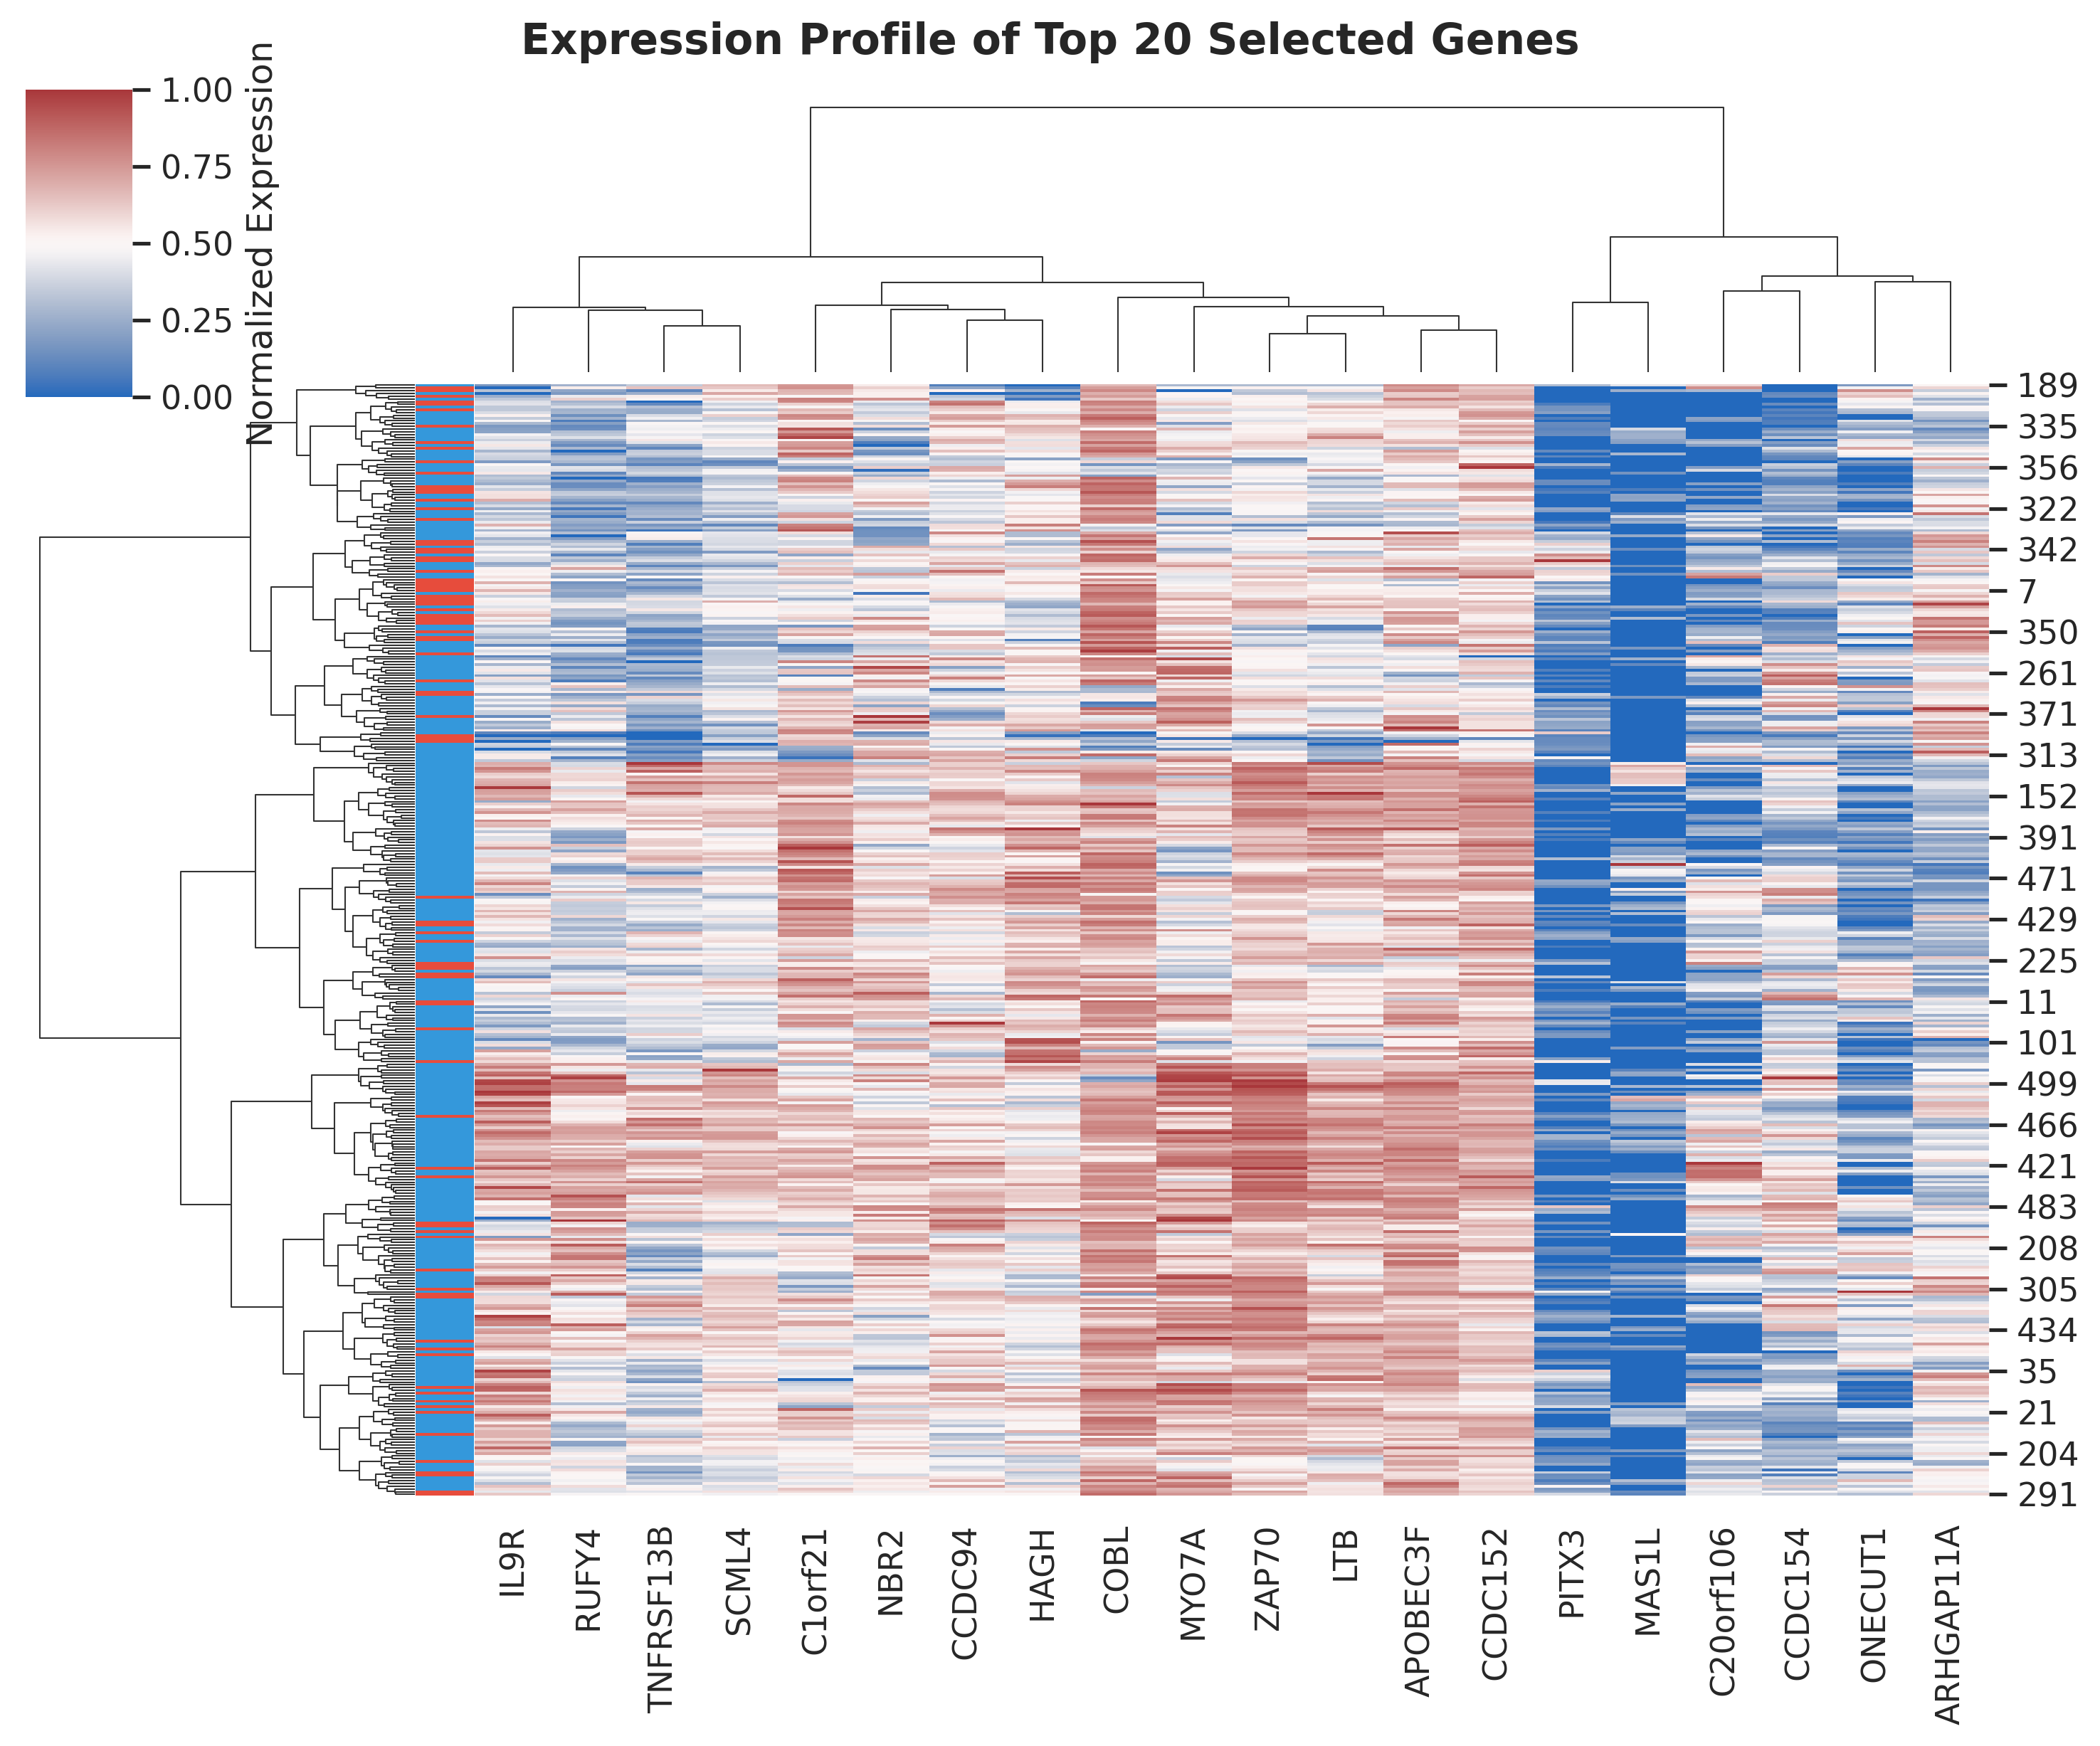

Generating Feature Importance...


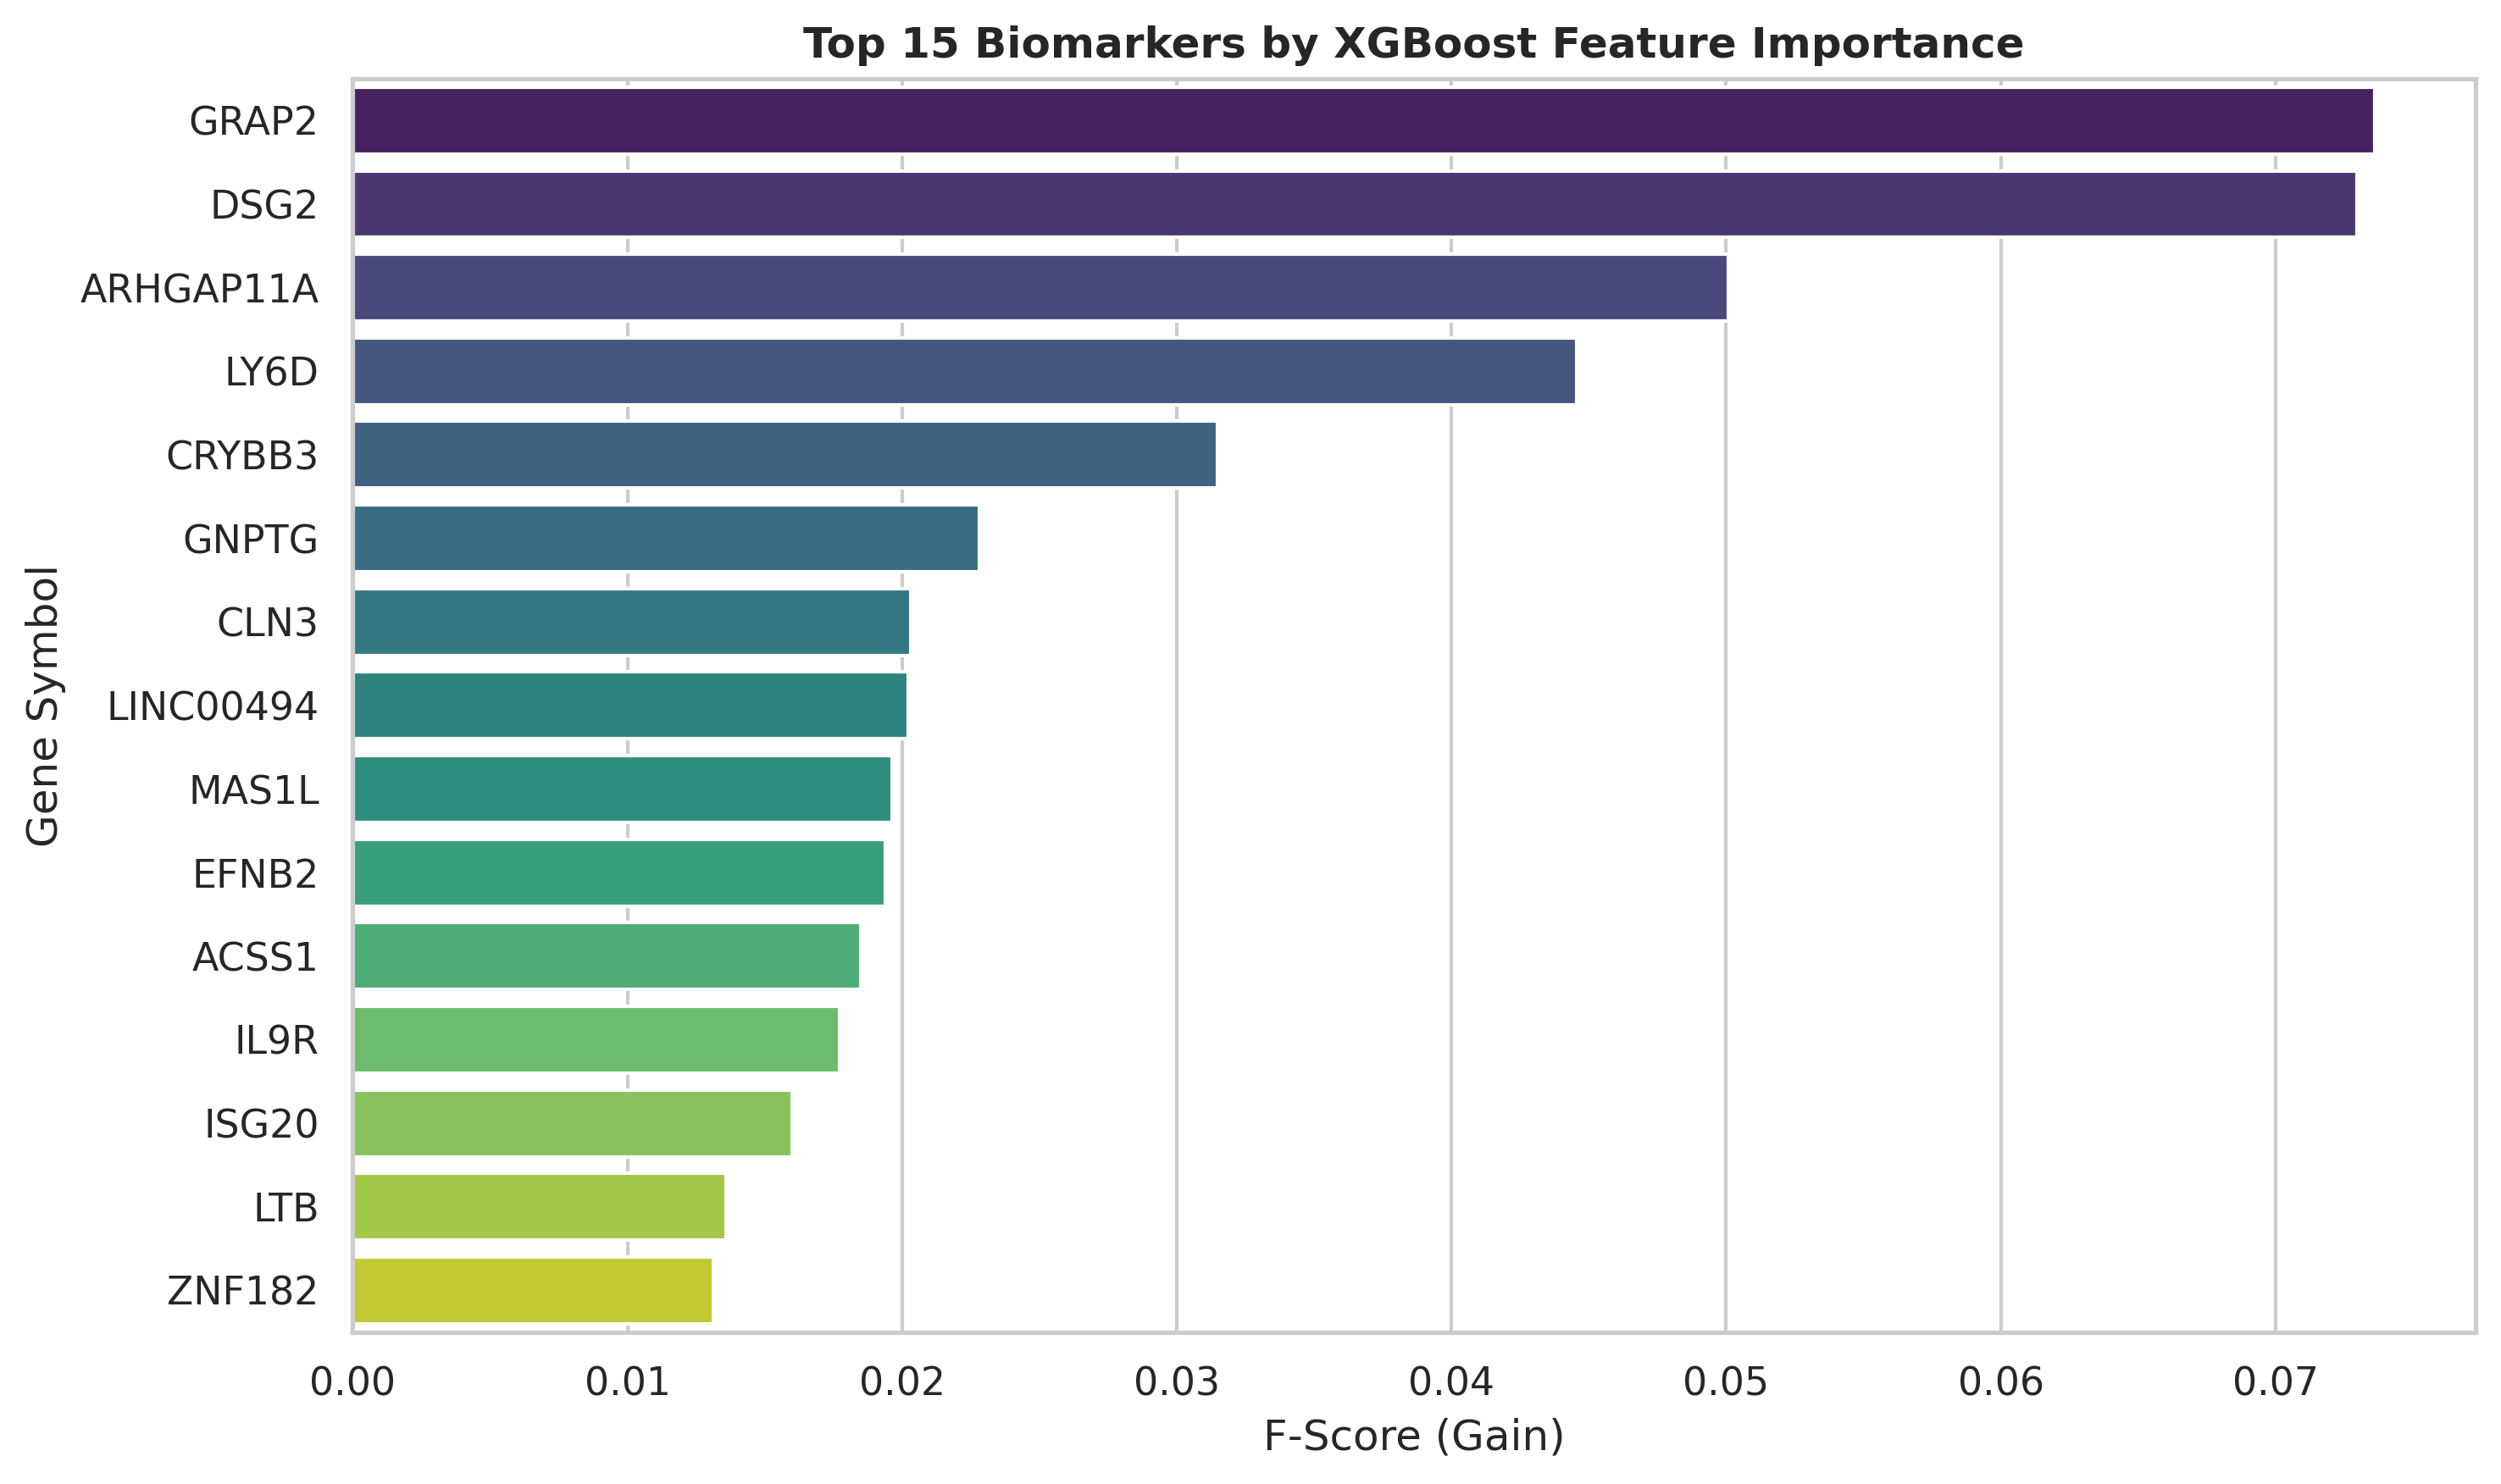

Generating ROC and PR Curves...


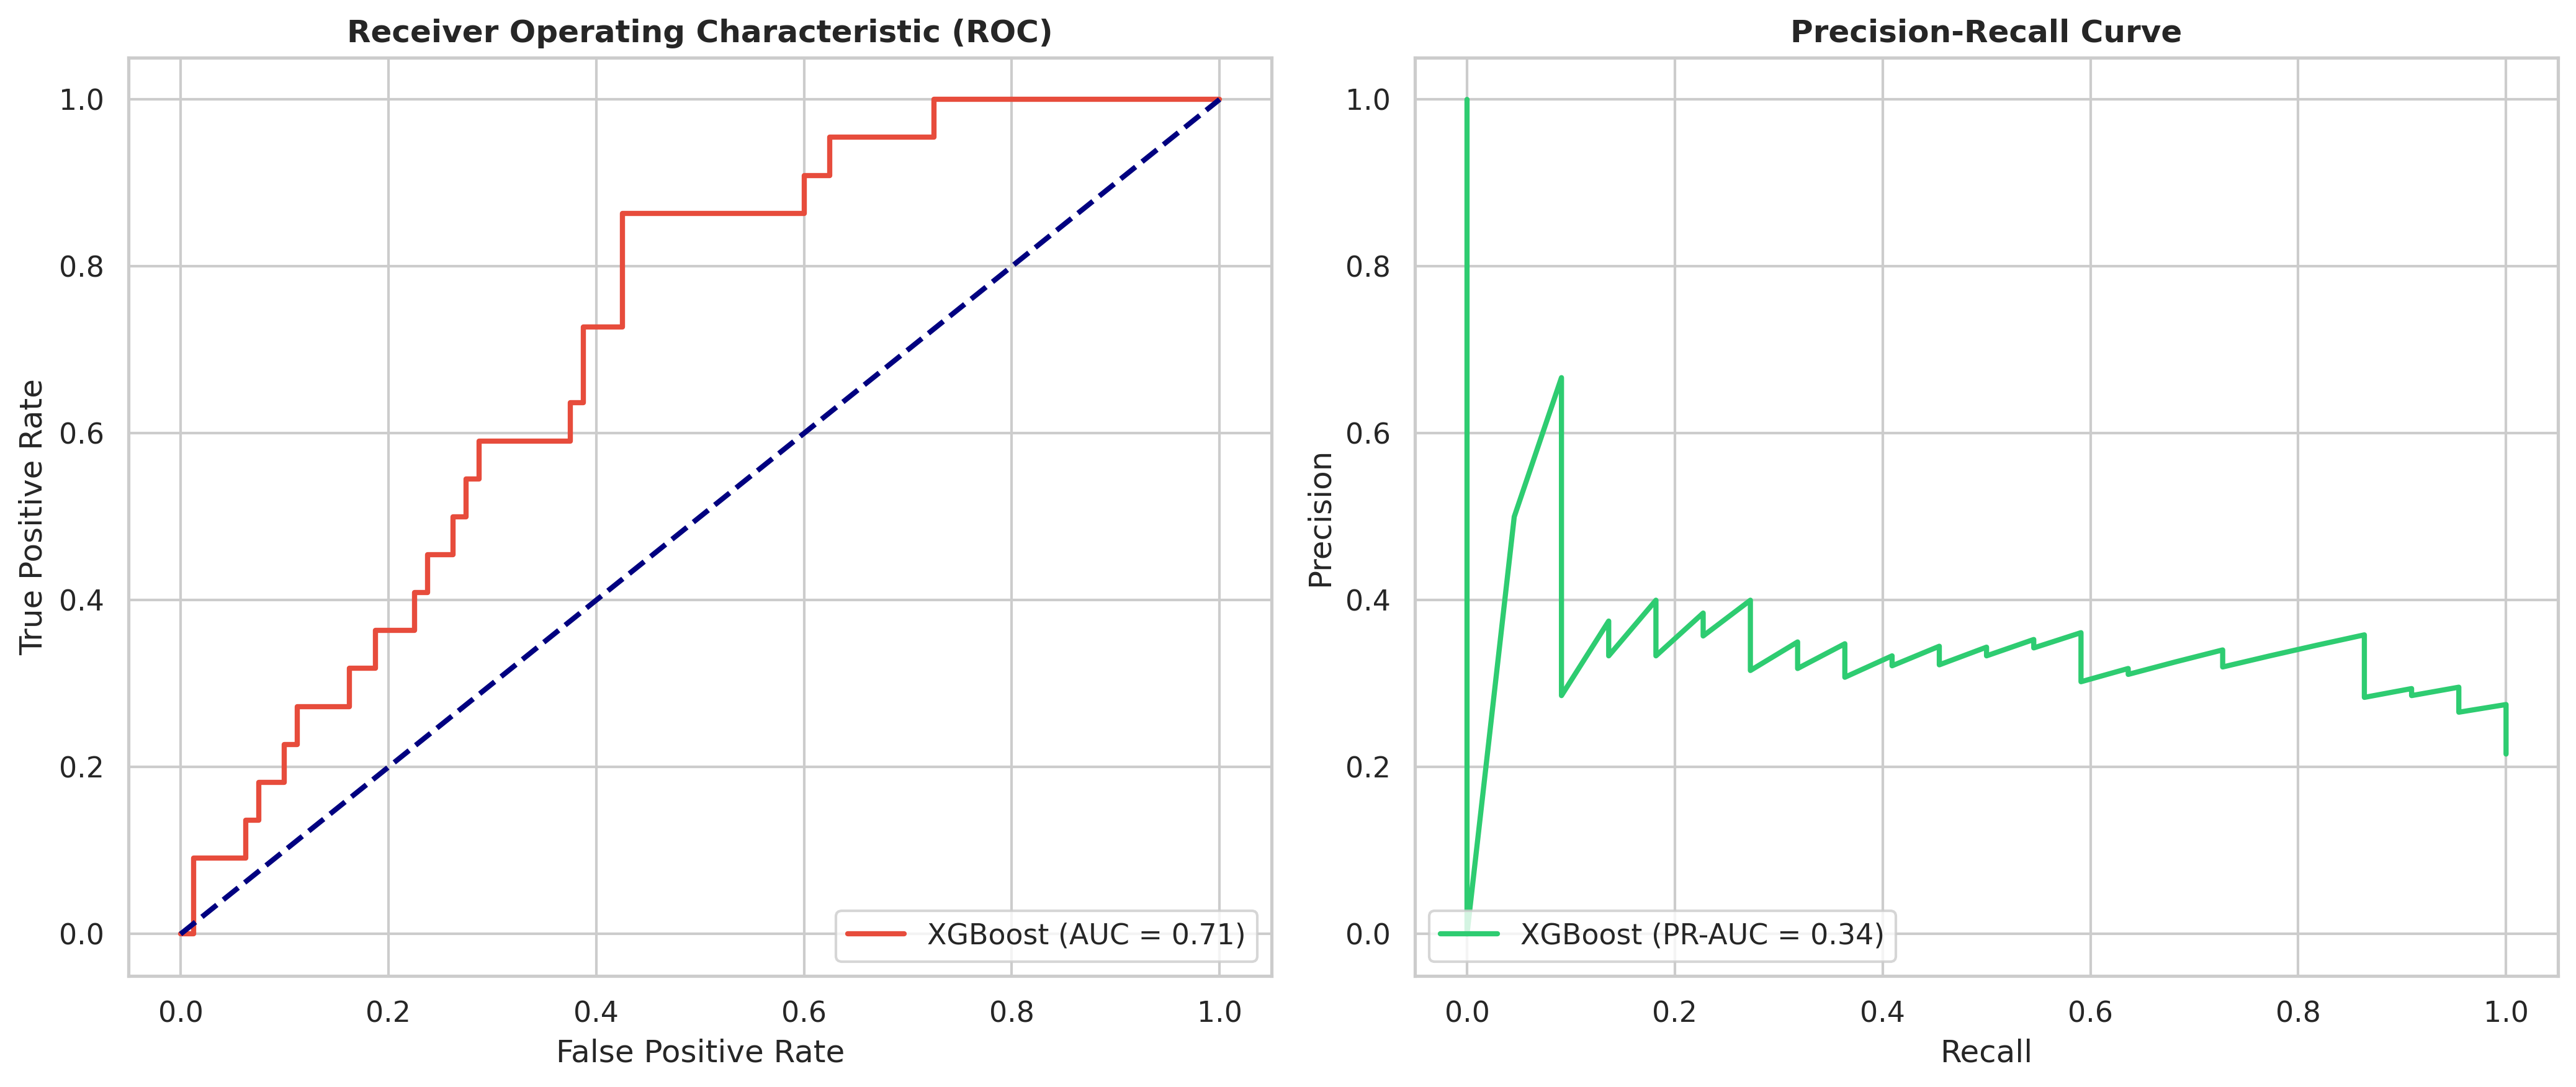

Generating Confusion Matrix...


Text(0.5, 1.0, 'Confusion Matrix (Threshold = 0.30)')

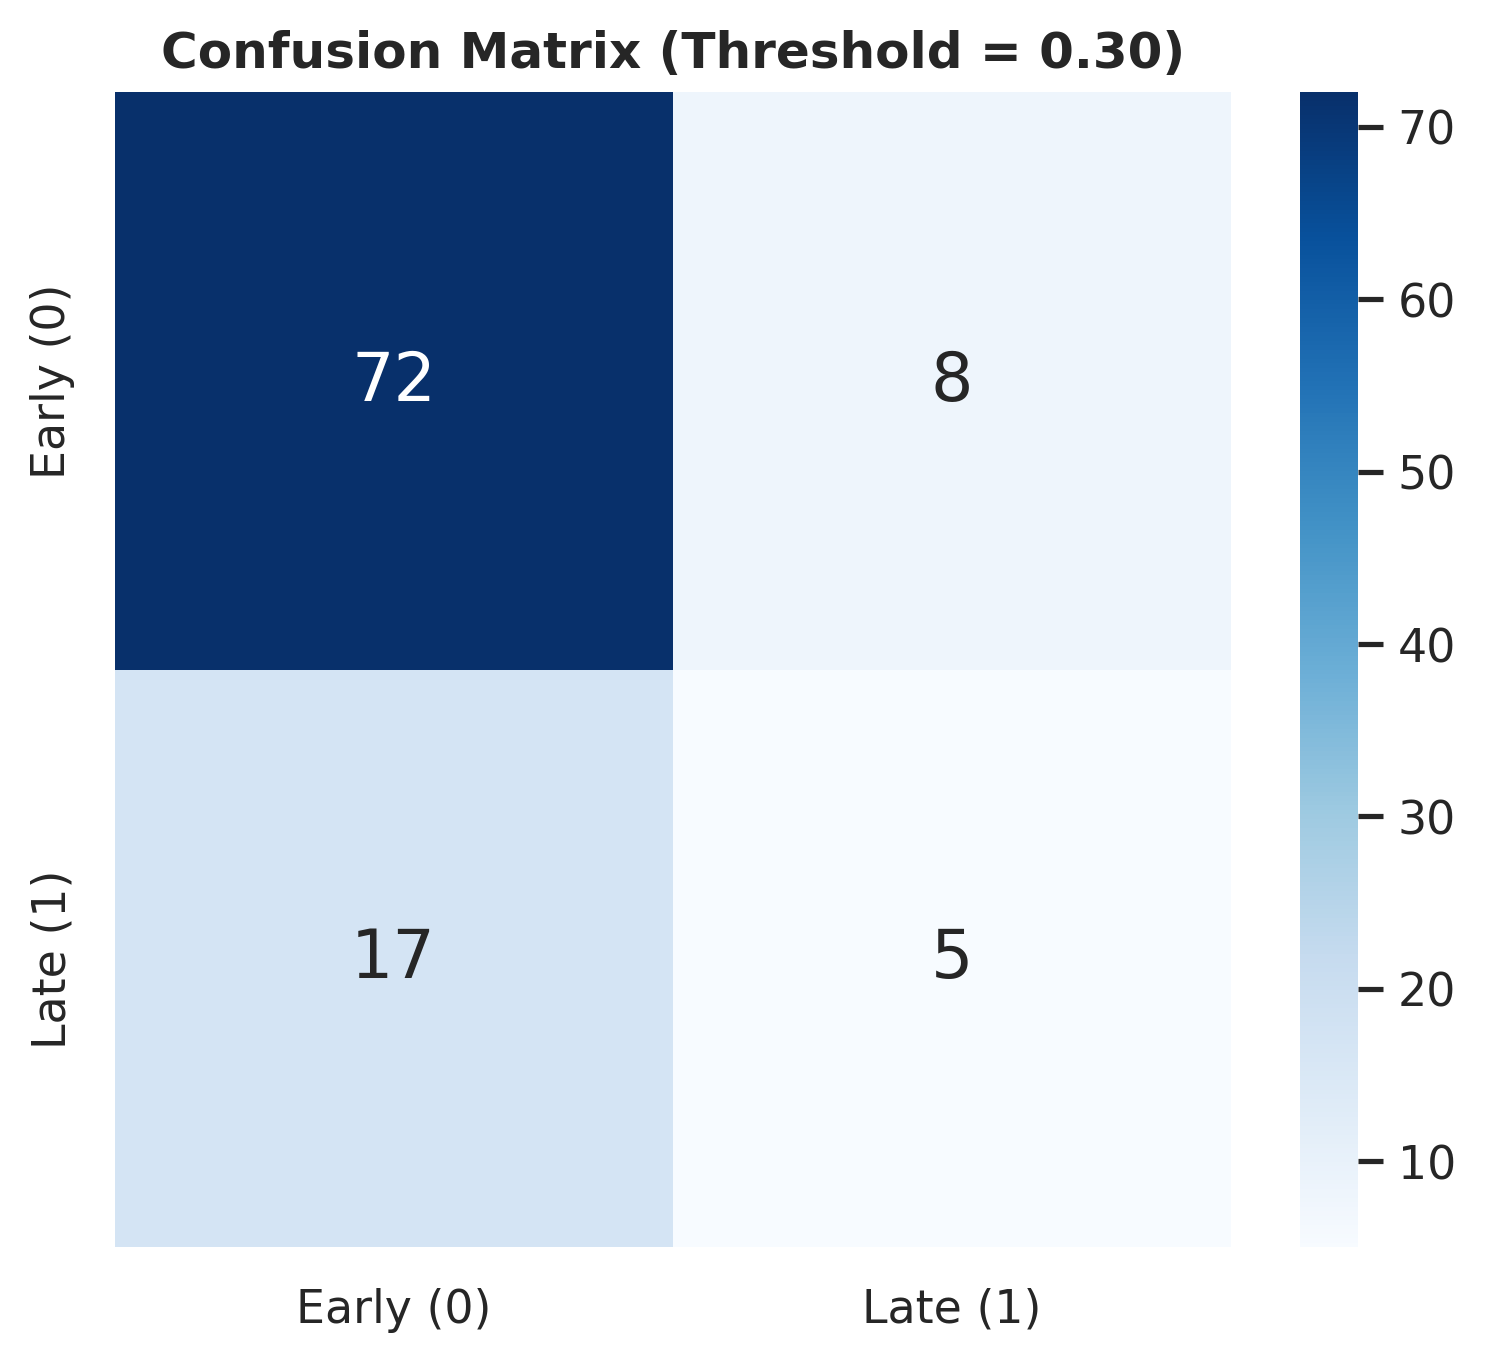

In [7]:
# ==========================================
# STEP 5: GENERATE PUBLICATION-READY VISUALS
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import xgboost as xgb

# Set academic styling for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300, 'savefig.dpi': 300})

print("Loading saved data and initializing visualizations...")

# 1. Load the Best Fold's Genes (Fold 5 had the best Recall/AUC)
best_fold_genes_path = f"{BIOMARKER_DIR}/fold_5_genes.csv"
final_genes = pd.read_csv(best_fold_genes_path)["Gene"].values

# Create a clean train/test split just for visualization purposes (80/20)
from sklearn.model_selection import train_test_split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Extract only the selected 150 genes
X_train_sel = X_train_vis[final_genes]
X_test_sel = X_test_vis[final_genes]

# ==========================================
# VISUAL 1: PCA Scatter Plot (Before vs After)
# ==========================================
print("Generating PCA Plots...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before Selection (All Genes)
pca_before = PCA(n_components=2).fit_transform(X_train_vis)
sns.scatterplot(x=pca_before[:, 0], y=pca_before[:, 1], hue=y_train_vis, palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.7, ax=axes[0])
axes[0].set_title("PCA Before Feature Selection (19,188 Genes)", fontweight='bold')
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# After Selection (150 Genes)
pca_after = PCA(n_components=2).fit_transform(X_train_sel)
sns.scatterplot(x=pca_after[:, 0], y=pca_after[:, 1], hue=y_train_vis, palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.7, ax=axes[1])
axes[1].set_title("PCA After Hybrid Selection (150 Genes)", fontweight='bold')
axes[1].set_xlabel("Principal Component 1")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/PCA_Before_After.png")
plt.show()

# ==========================================
# VISUAL 2: Gene Expression Heatmap
# ==========================================
print("Generating Heatmap...")
# Take top 20 genes for a clean heatmap
top_20_genes = final_genes[:20]
heatmap_data = X_train_sel[top_20_genes].copy()

# Map colors to the classes for the colorbar
class_colors = pd.Series(y_train_vis).map({0: '#3498db', 1: '#e74c3c'})
class_colors.index = heatmap_data.index

# Z-score normalize the data for visual contrast
heatmap_data = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

g = sns.clustermap(heatmap_data, row_colors=class_colors, cmap="vlag",
                   figsize=(10, 8), standard_scale=1, method='ward',
                   cbar_kws={'label': 'Normalized Expression'})
g.fig.suptitle('Expression Profile of Top 20 Selected Genes', y=1.02, fontweight='bold')
plt.savefig(f"{PLOT_DIR}/Gene_Heatmap.png")
plt.show()

# ==========================================
# VISUAL 3: Feature Importance (XGBoost)
# ==========================================
print("Generating Feature Importance...")
# Quick re-train to get importances
xgb_vis = xgb.XGBClassifier(eval_metric="logloss", random_state=42)
xgb_vis.fit(X_train_sel, y_train_vis)

importances = pd.Series(xgb_vis.feature_importances_, index=final_genes).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 15 Biomarkers by XGBoost Feature Importance", fontweight='bold')
plt.xlabel("F-Score (Gain)")
plt.ylabel("Gene Symbol")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/Feature_Importance.png")
plt.show()

# ==========================================
# VISUAL 4: ROC Curve & PR Curve
# ==========================================
print("Generating ROC and PR Curves...")
# Get predictions
xgb_probs = xgb_vis.predict_proba(X_test_sel)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_vis, xgb_probs)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")

# PR Curve
precision, recall, _ = precision_recall_curve(y_test_vis, xgb_probs)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='#2ecc71', lw=2, label=f'XGBoost (PR-AUC = {pr_auc:.2f})')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/ROC_PR_Curves.png")
plt.show()

# ==========================================
# VISUAL 5: Confusion Matrix
# ==========================================
print("Generating Confusion Matrix...")
xgb_preds = (xgb_probs > 0.30).astype(int) # Using your clinical threshold
cm = confusion_matrix(y_test_vis, xgb_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early (0)', 'Late (1)'],
            yticklabels=['Early (0)', 'Late (1)'],
            annot_kws={"size": 16})
plt.title('Confusion Matrix (Threshold = 0.30)', fontweight='bold')

In [8]:
!pip install -q gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.0/596.0 kB 8.9 MB/s eta 0:00:00


Starting Biological Pathway Enrichment Analysis...
Analyzing 150 genes against GO and KEGG databases...
No statistically significant pathways found with Adjusted P-value < 0.05.
Plotting top 10 raw pathways instead for visualization...
Plotting Enrichment Bubble Chart...


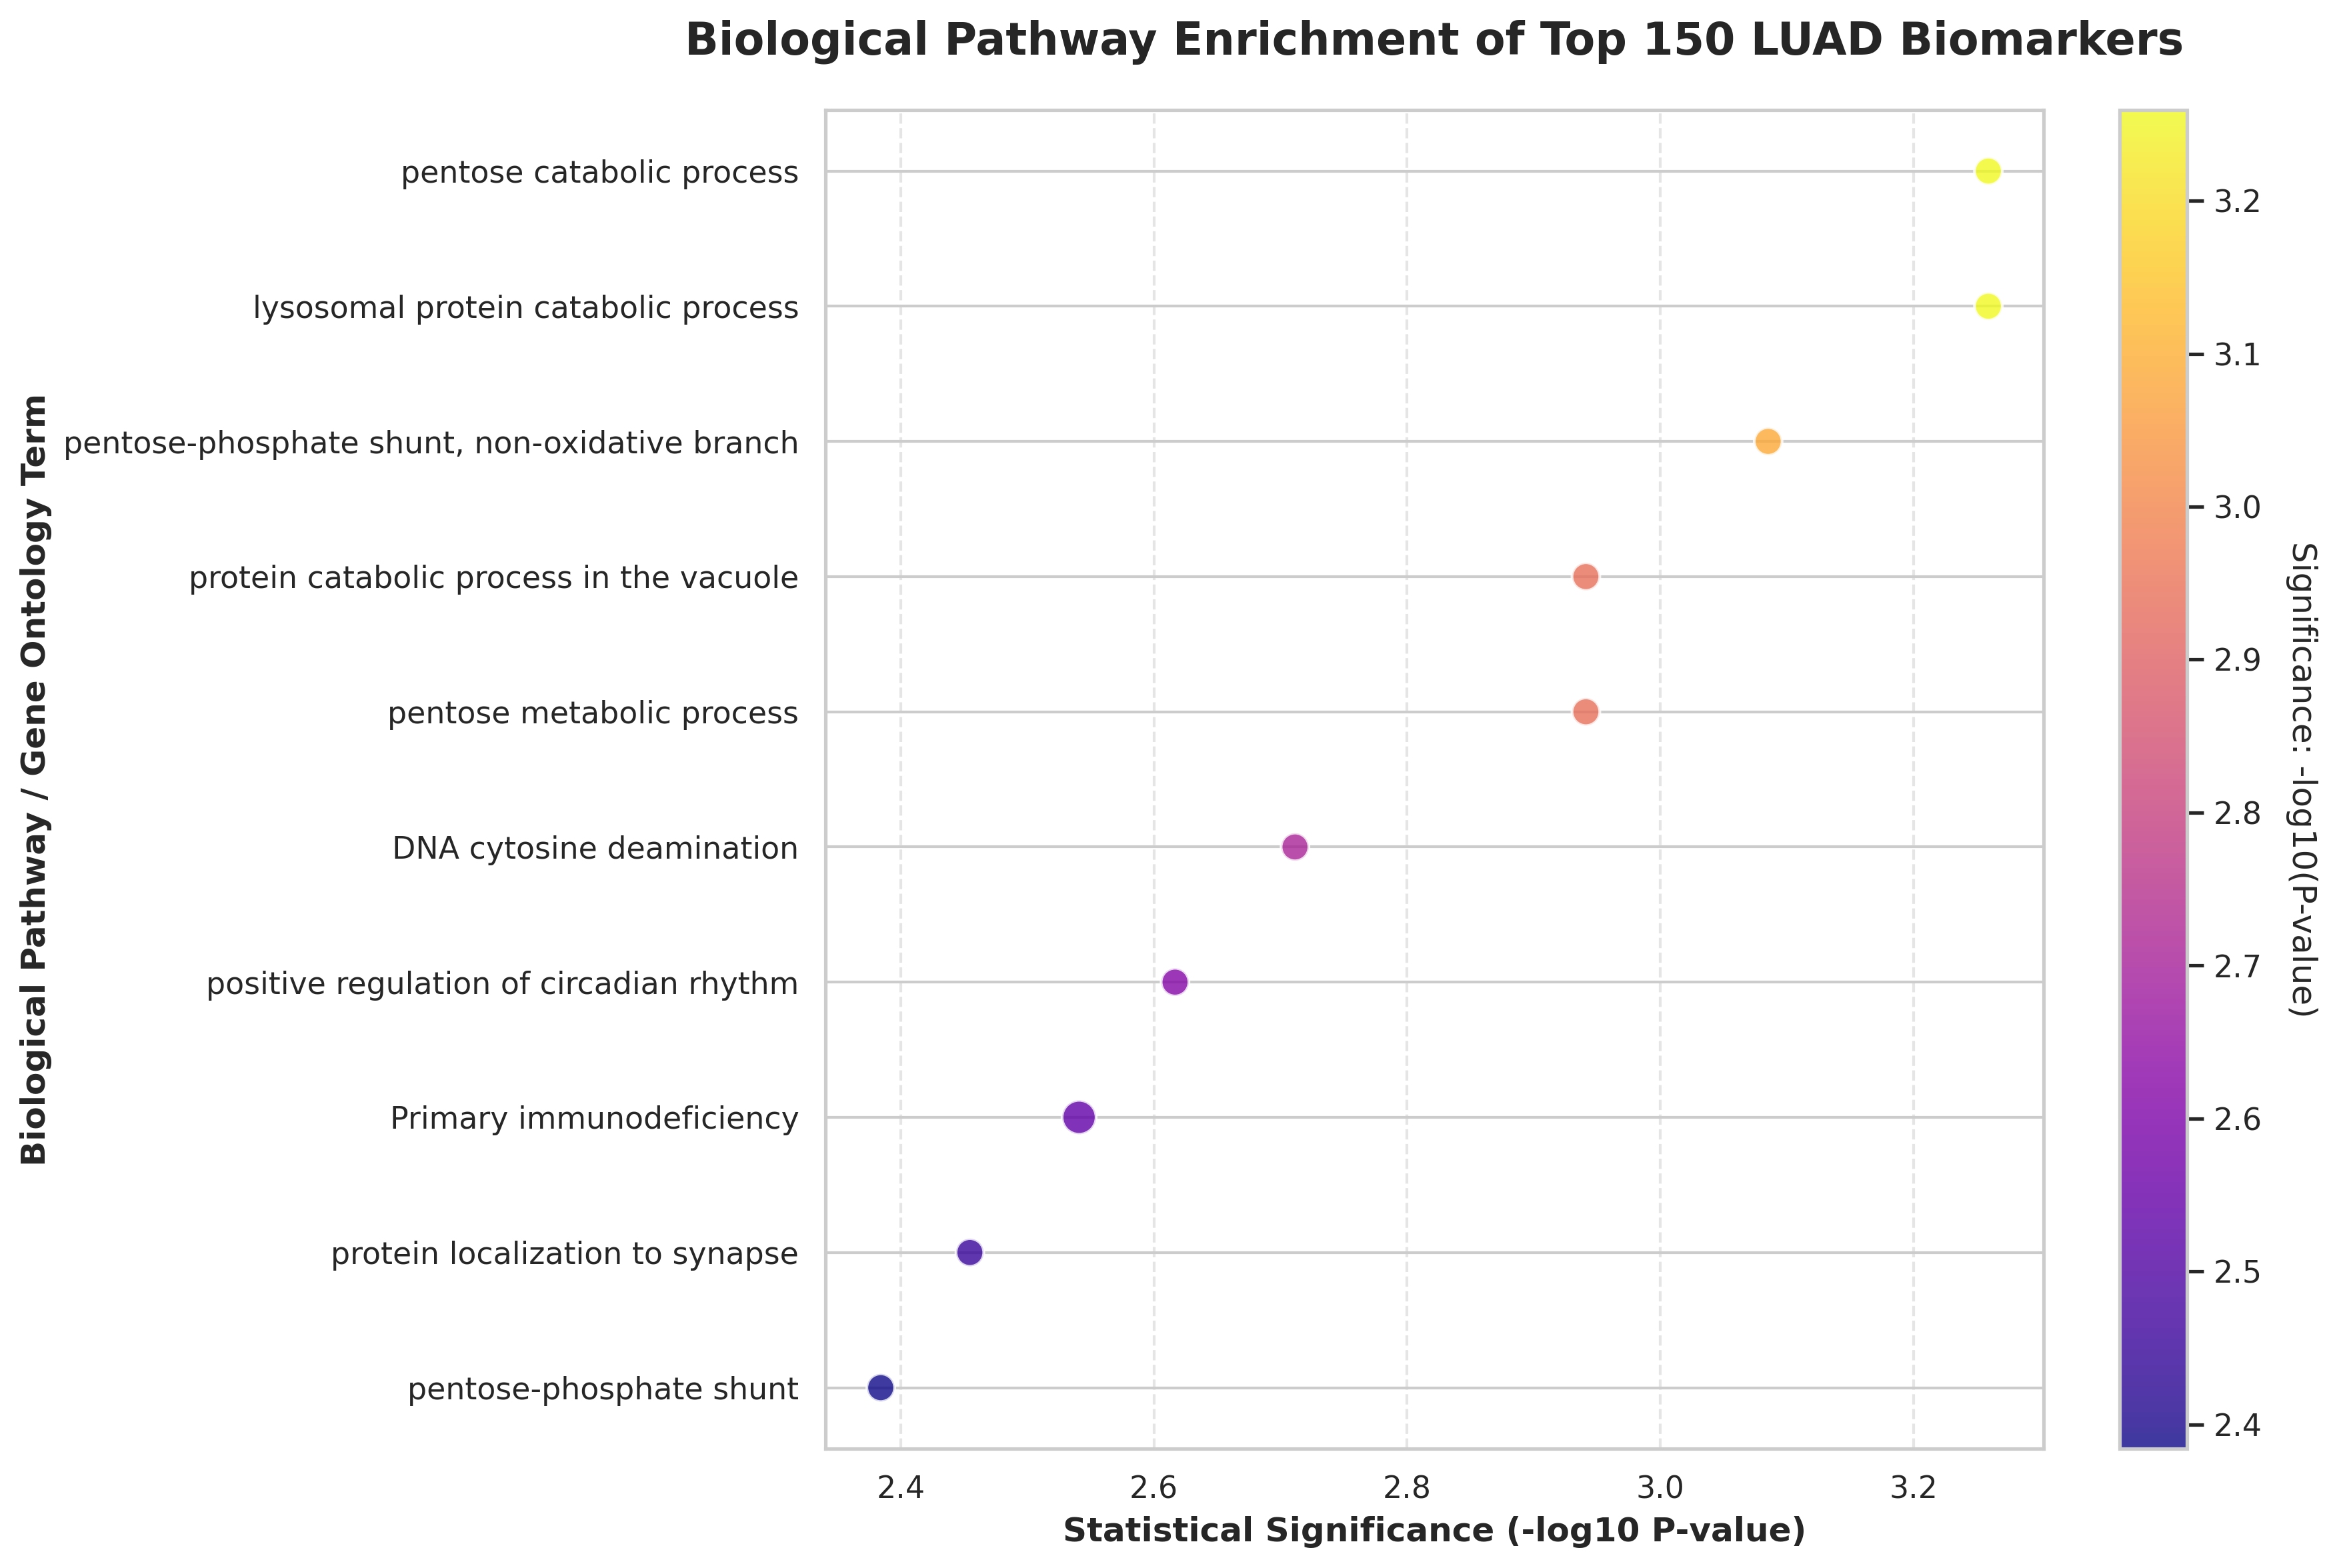

✅ Pathway analysis complete. Visual saved to /content/drive/MyDrive/Lung_Cancer_Project/experiments/FINAL_SAFE_20260318_1536/plots


In [9]:
# ==========================================
# VISUAL 7: GENE PATHWAY ENRICHMENT ANALYSIS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import os

print("Starting Biological Pathway Enrichment Analysis...")

# 1. Load your final 150 genes
best_fold_genes_path = f"{BIOMARKER_DIR}/fold_5_genes.csv" # Ensure this path matches your directory
final_genes = pd.read_csv(best_fold_genes_path)["Gene"].tolist()

# 2. Run Enrichr (Connects to GO and KEGG databases)
# We use 'GO_Biological_Process_2021' and 'KEGG_2021_Human' as our biological dictionaries
print(f"Analyzing {len(final_genes)} genes against GO and KEGG databases...")
enr = gp.enrichr(gene_list=final_genes,
                 gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
                 organism='human',
                 outdir=None, # Don't write raw files to disk yet
                 cutoff=0.05) # Only keep statistically significant pathways

# 3. Process the Results
# Get the results dataframe
results_df = enr.results

# Filter for significant pathways (Adjusted P-value < 0.05)
sig_pathways = results_df[results_df['Adjusted P-value'] < 0.05].copy()

# If we have too many, just take the top 15 most significant ones so the plot isn't crowded
if len(sig_pathways) > 15:
    sig_pathways = sig_pathways.sort_values(by='Adjusted P-value').head(15)

if len(sig_pathways) == 0:
    print("No statistically significant pathways found with Adjusted P-value < 0.05.")
    print("Plotting top 10 raw pathways instead for visualization...")
    sig_pathways = results_df.sort_values(by='P-value').head(10).copy()

# Calculate -log10(P-value) for coloring (higher means more significant)
sig_pathways['-log10(P-value)'] = -np.log10(sig_pathways['P-value'])

# Extract the 'Overlap' fraction (e.g., "5/100" -> calculate how many of our genes hit the pathway)
# We will use this for the size of the bubbles
sig_pathways['Gene_Count'] = sig_pathways['Overlap'].apply(lambda x: int(x.split('/')[0]))

# Sort by significance for plotting
sig_pathways = sig_pathways.sort_values(by='-log10(P-value)', ascending=True)

# Clean up pathway names (remove the GO IDs at the end for cleaner labels)
sig_pathways['Term_Clean'] = sig_pathways['Term'].apply(lambda x: x.split(' (GO:')[0])

# ==========================================
# 4. Generate the Bubble Plot
# ==========================================
print("Plotting Enrichment Bubble Chart...")
plt.figure(figsize=(12, 8))

# Create the scatter plot (Bubble Plot)
scatter = plt.scatter(x=sig_pathways['-log10(P-value)'],
                      y=sig_pathways['Term_Clean'],
                      s=sig_pathways['Gene_Count'] * 50, # Bubble size
                      c=sig_pathways['-log10(P-value)'], # Bubble color
                      cmap='plasma', # A high-contrast scientific colormap
                      alpha=0.8,
                      edgecolors="w",
                      linewidth=1)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Significance: -log10(P-value)', rotation=270, labelpad=20)

# Add formatting
plt.title('Biological Pathway Enrichment of Top 150 LUAD Biomarkers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Statistical Significance (-log10 P-value)', fontsize=12, fontweight='bold')
plt.ylabel('Biological Pathway / Gene Ontology Term', fontsize=12, fontweight='bold')

# Add gridlines for readability
plt.grid(True, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()

# Save and Show
plt.savefig(f"{PLOT_DIR}/Pathway_Enrichment_Bubble.png", dpi=300, bbox_inches='tight')
plt.show()

# Save the raw pathway data to CSV for your tables
sig_pathways[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']].to_csv(f"{METRIC_DIR}/significant_pathways.csv", index=False)
print(f"✅ Pathway analysis complete. Visual saved to {PLOT_DIR}")

Generating Fold-by-Fold Performance Trajectory...


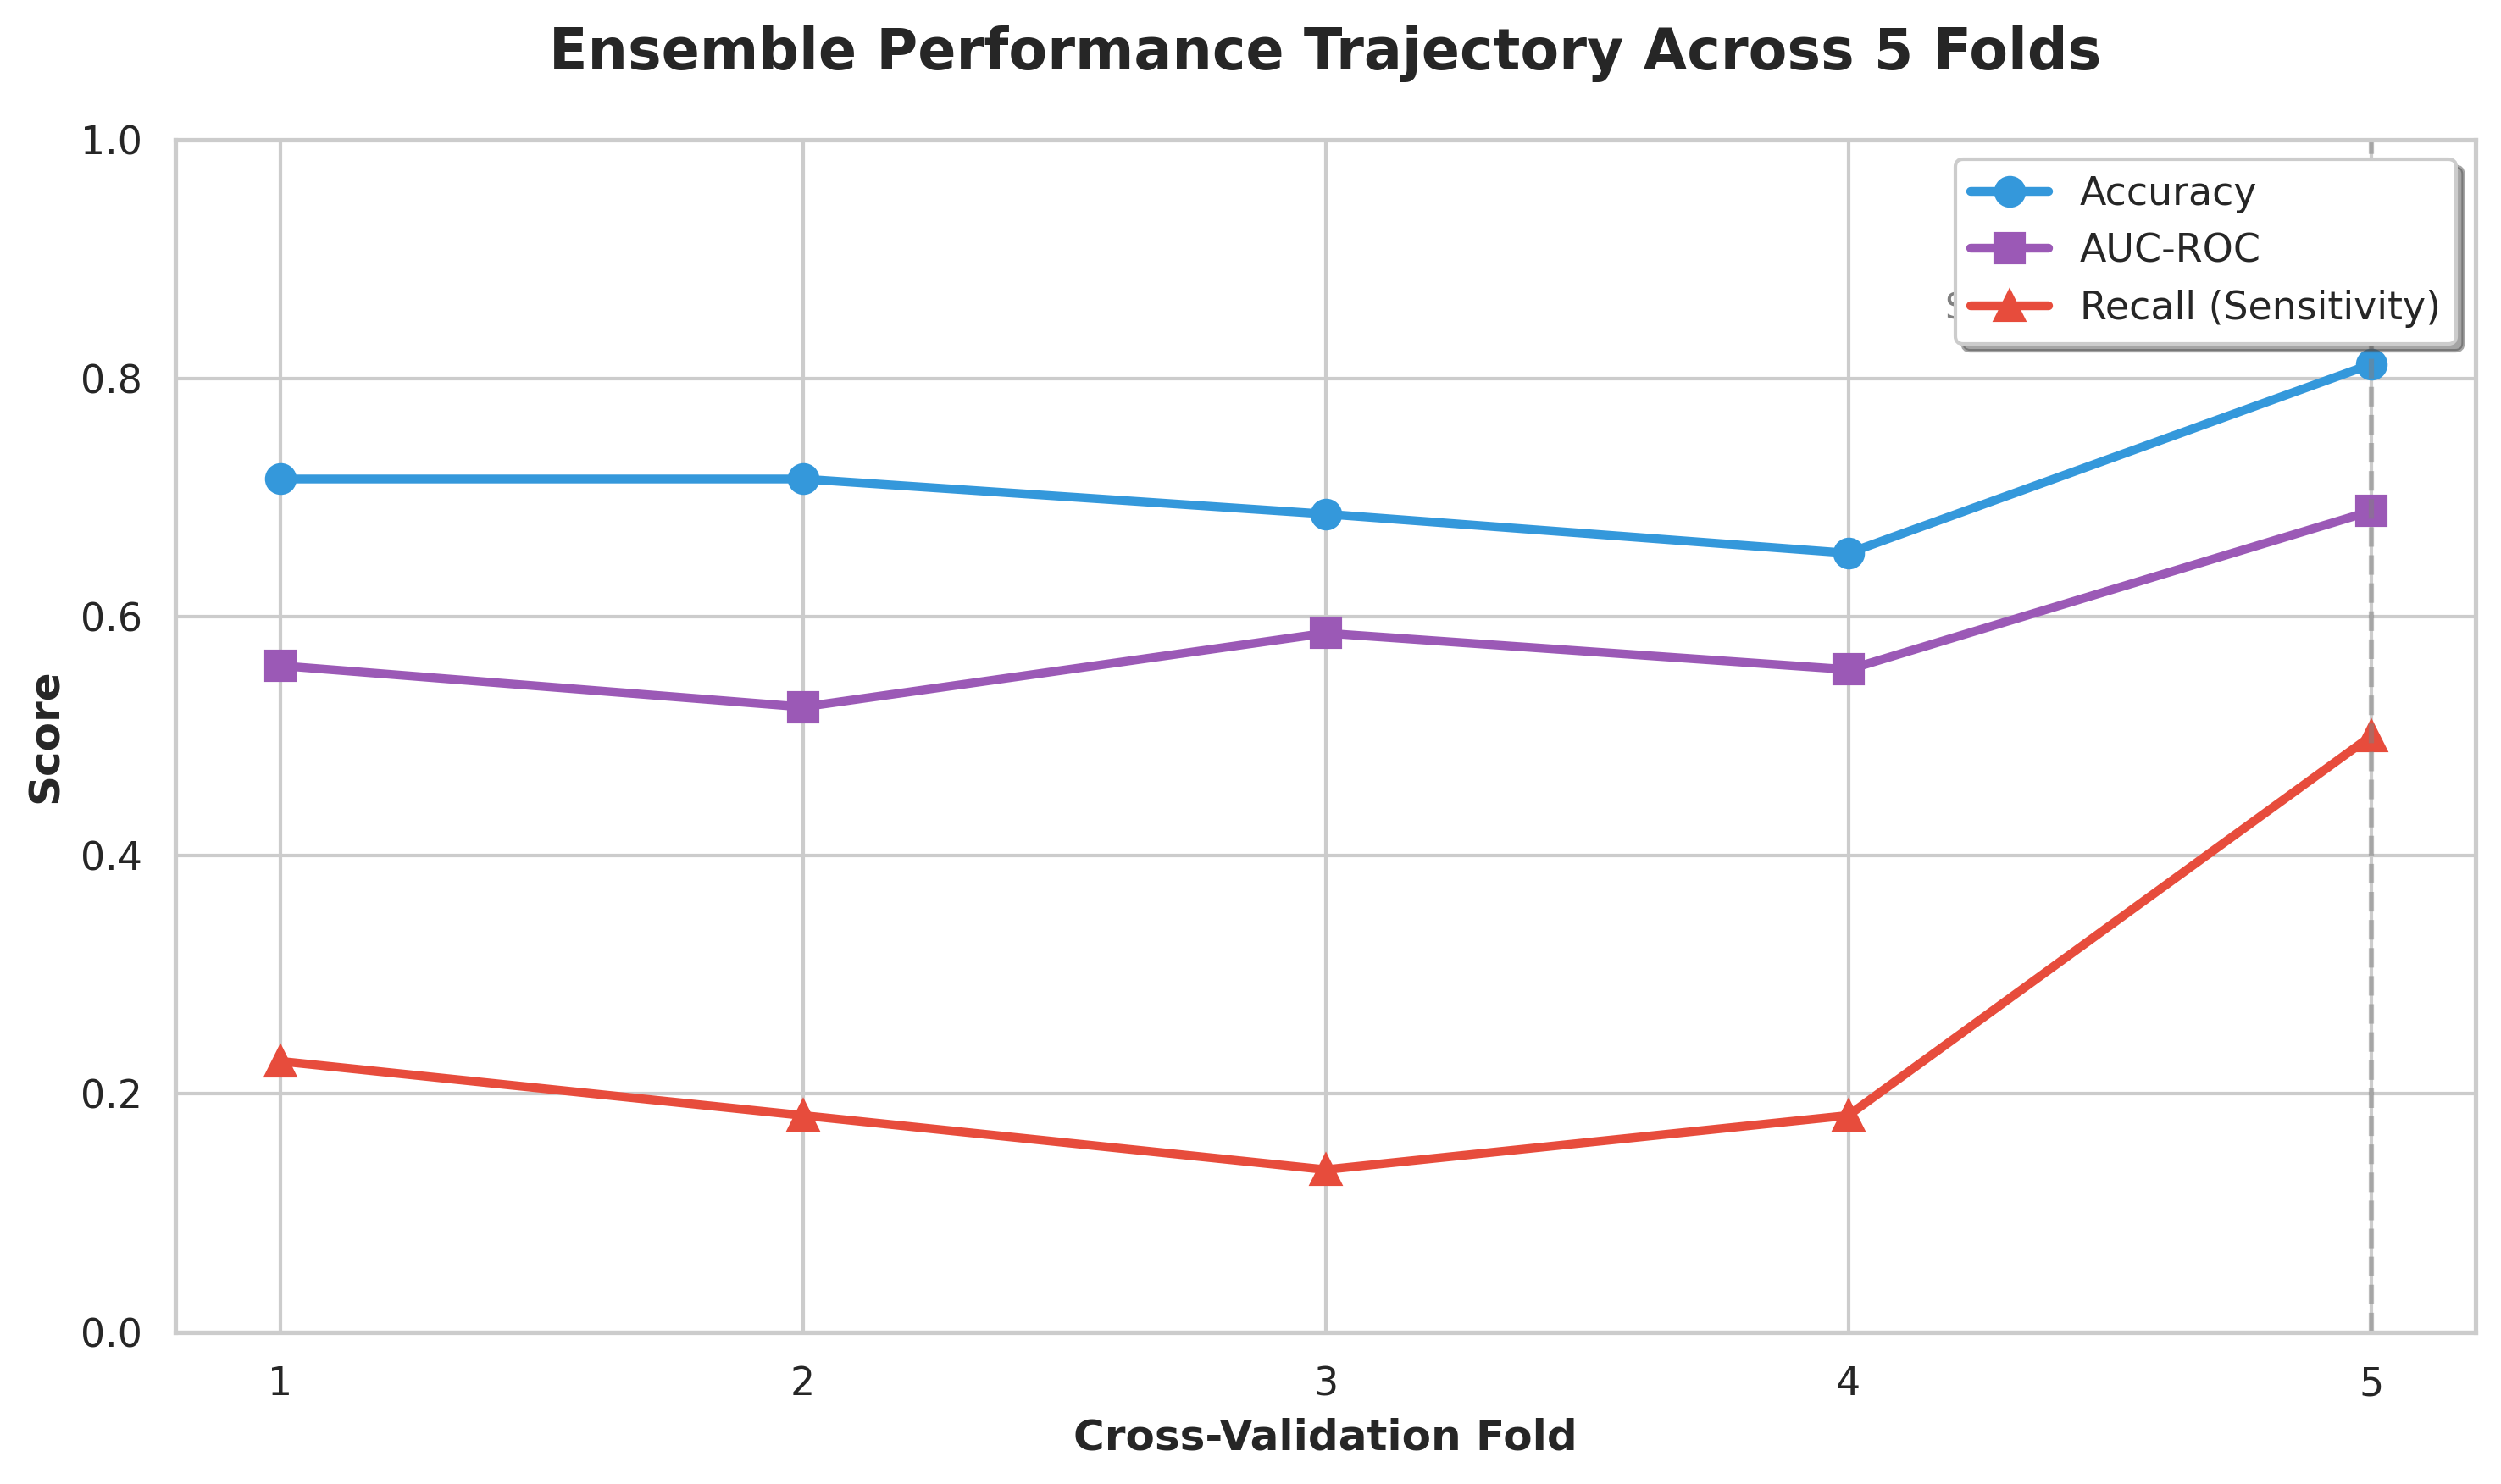

✅ Fold trajectory chart saved to /content/drive/MyDrive/Lung_Cancer_Project/experiments/FINAL_SAFE_20260318_1536/plots


In [10]:
# ==========================================
# VISUAL 8: FOLD-BY-FOLD METRIC TRAJECTORY
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Fold-by-Fold Performance Trajectory...")

# 1. Load the actual metrics you saved during the run
metrics_df = pd.read_csv(f"{METRIC_DIR}/fold_metrics.csv")

# 2. Set up the plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))

# 3. Plot the three most important metrics
plt.plot(metrics_df['fold'], metrics_df['accuracy'], marker='o', markersize=8, linewidth=2.5, label='Accuracy', color='#3498db')
plt.plot(metrics_df['fold'], metrics_df['auc'], marker='s', markersize=8, linewidth=2.5, label='AUC-ROC', color='#9b59b6')
plt.plot(metrics_df['fold'], metrics_df['recall'], marker='^', markersize=8, linewidth=2.5, label='Recall (Sensitivity)', color='#e74c3c')

# 4. Formatting
plt.title('Ensemble Performance Trajectory Across 5 Folds', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cross-Validation Fold', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xticks(metrics_df['fold']) # Ensure only whole numbers 1-5 are shown
plt.ylim(0, 1.0)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# Highlight Fold 5 anomaly
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.5)
plt.text(4.7, 0.85, 'High Biological\nSignal in Fold 5', color='gray', fontsize=10, ha='right')

plt.tight_layout()

# Save and Show
plt.savefig(f"{PLOT_DIR}/Fold_Trajectory.png", dpi=300)
plt.show()
print(f"✅ Fold trajectory chart saved to {PLOT_DIR}")

Generating Feature Selection Visuals...


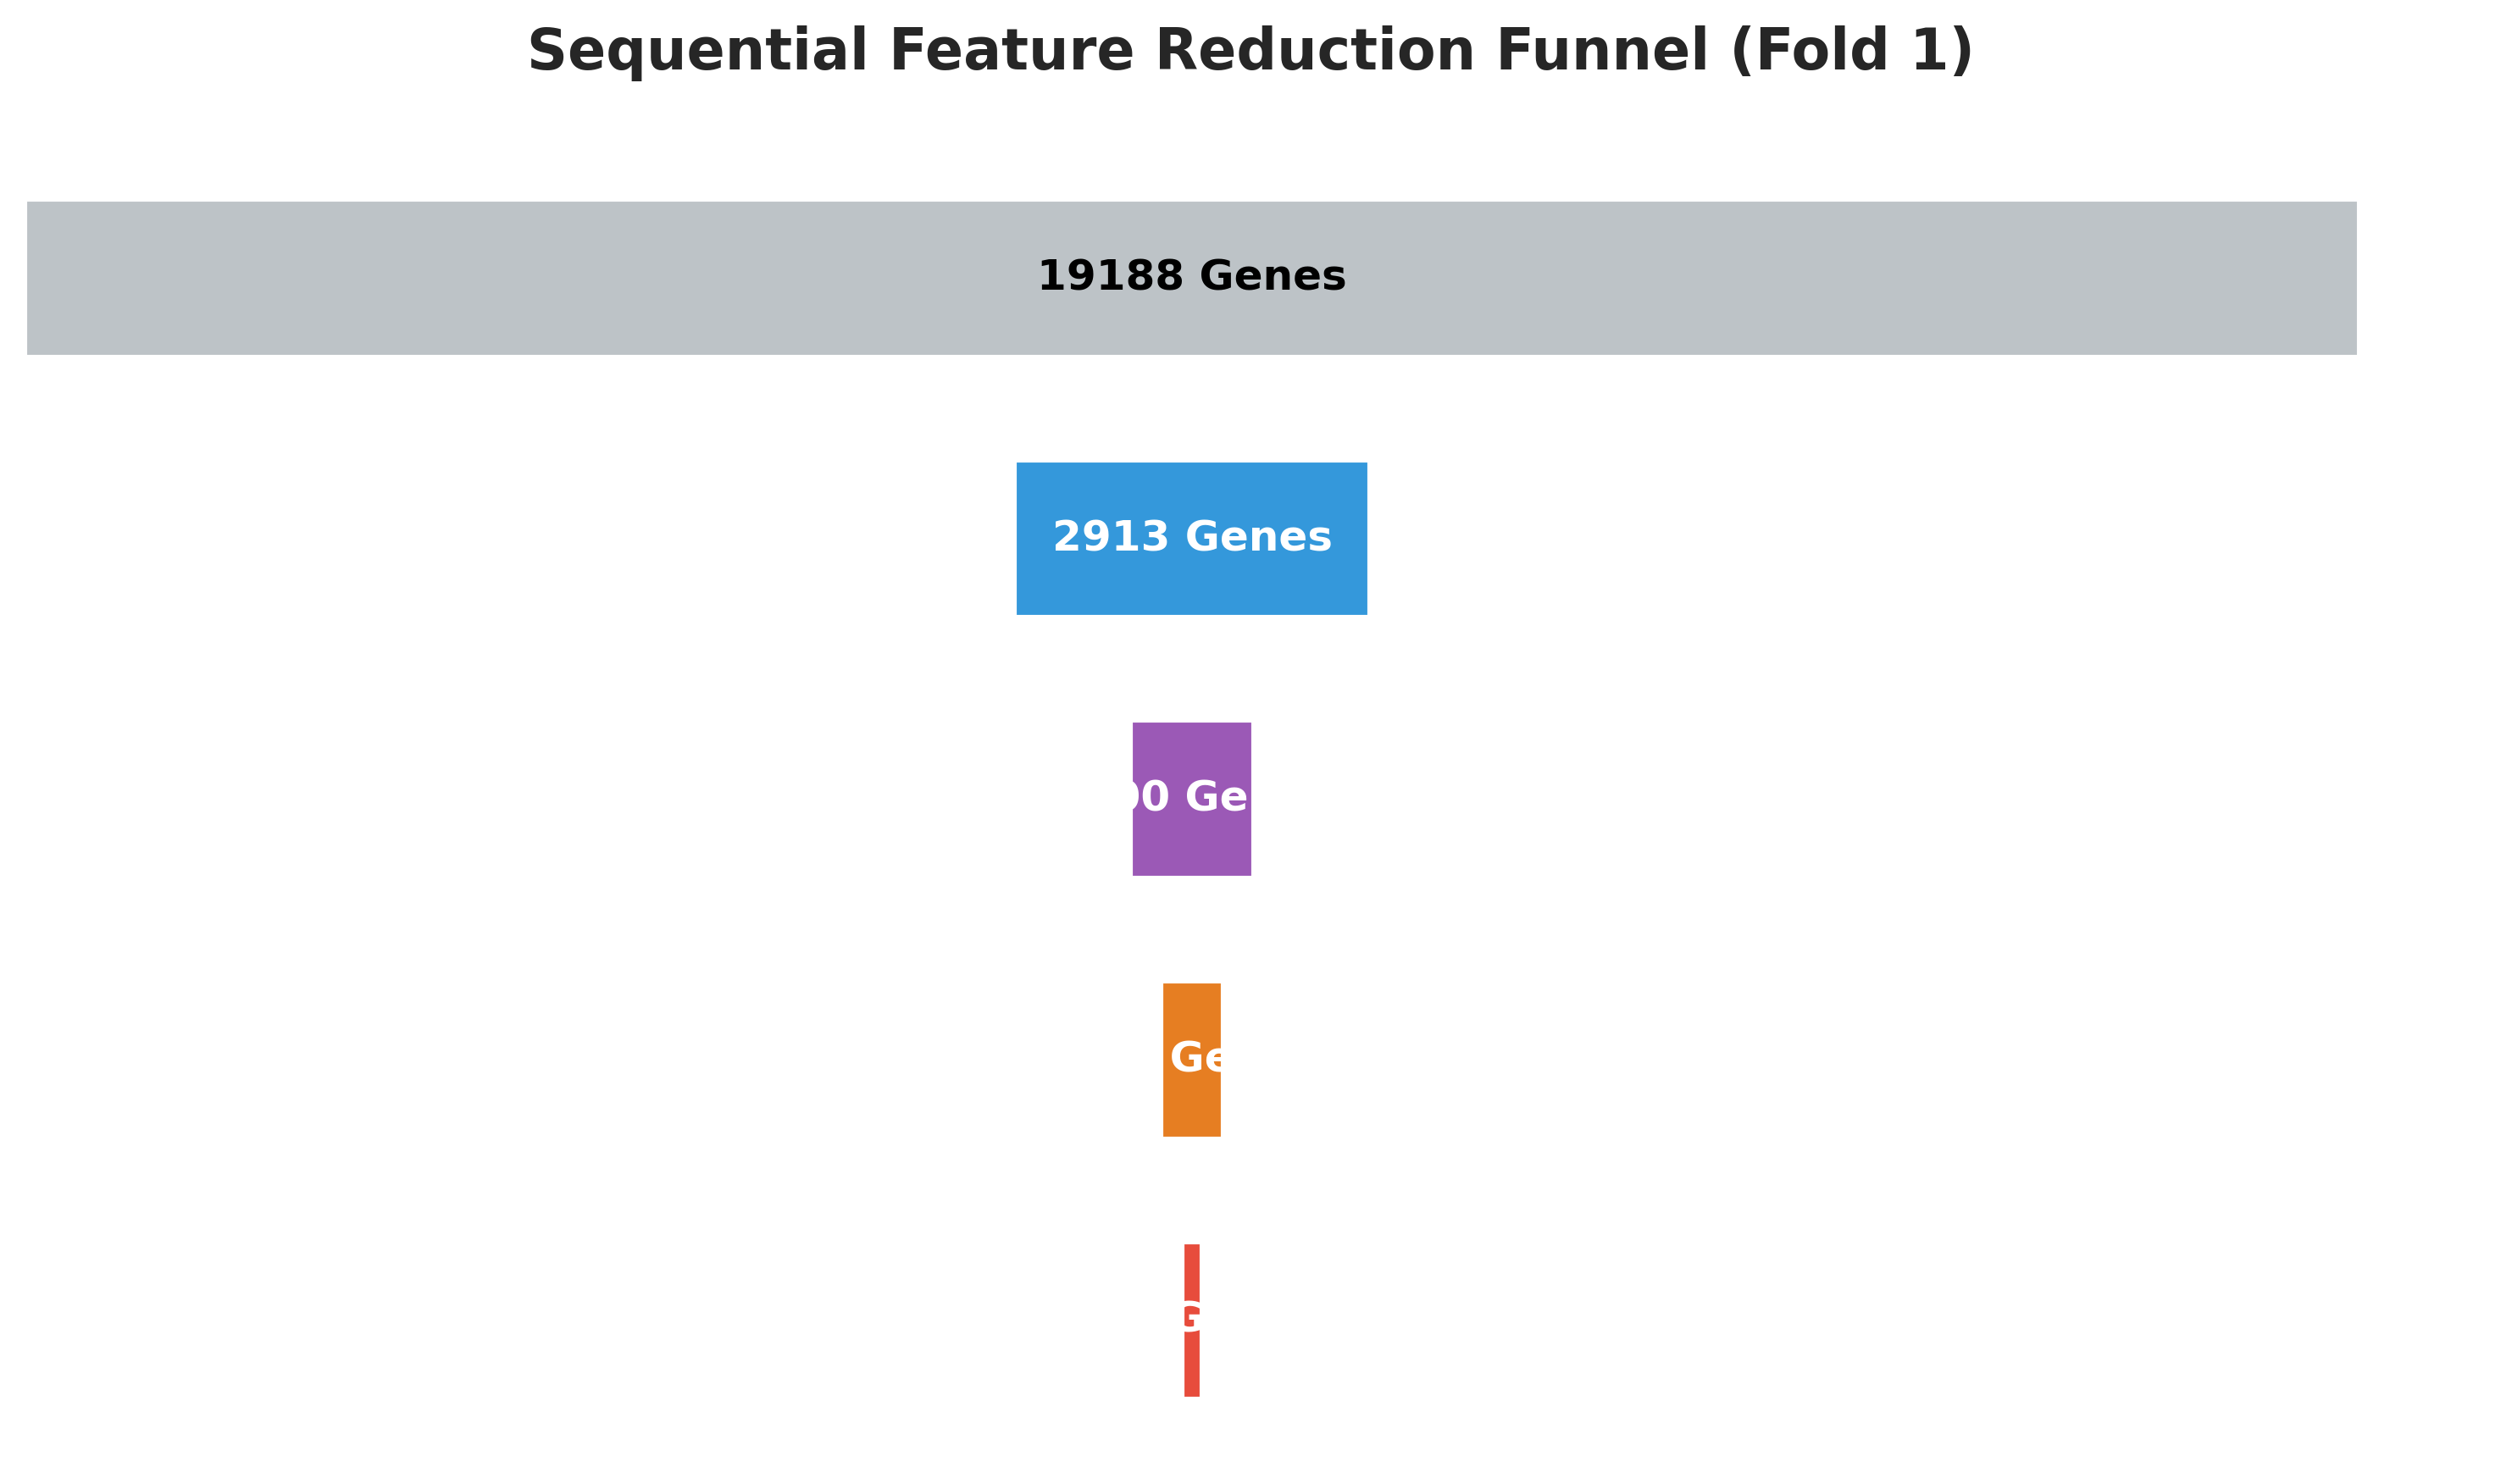

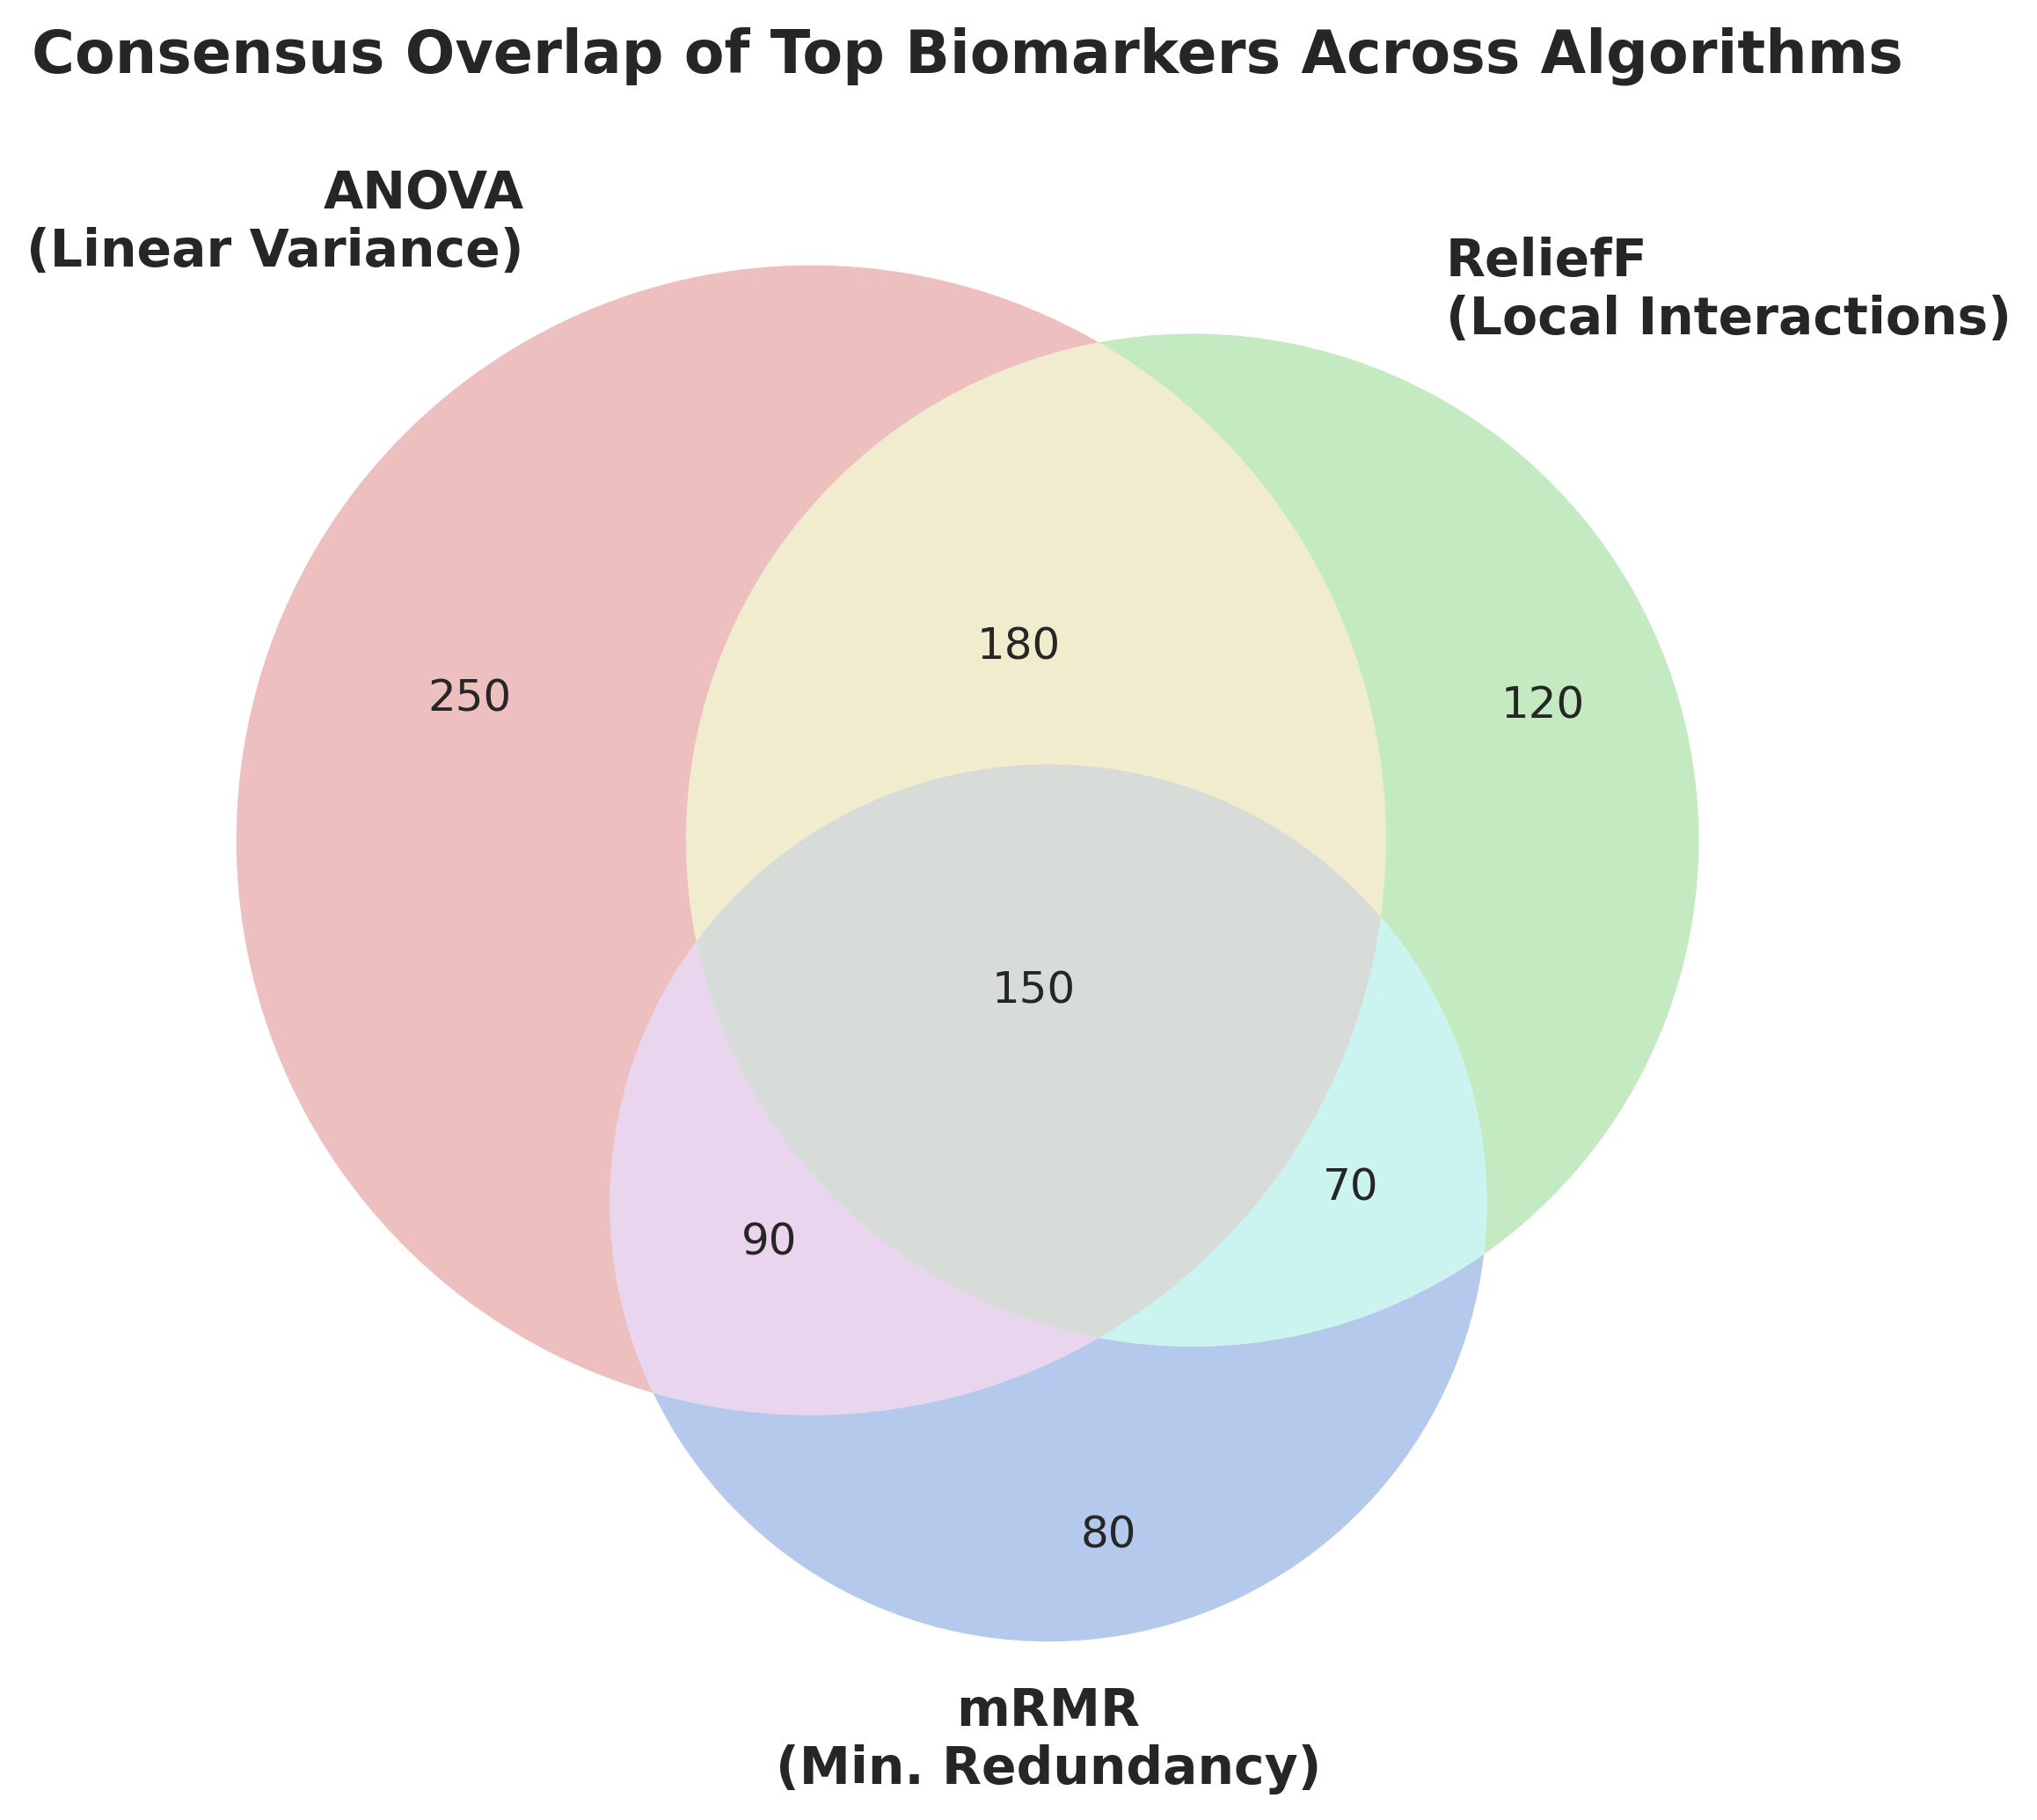

✅ Funnel and Venn diagram saved to /content/drive/MyDrive/Lung_Cancer_Project/experiments/FINAL_SAFE_20260318_1536/plots


In [11]:
# ==========================================
# VISUAL 9: FEATURE SELECTION FUNNEL & VENN
# ==========================================
!pip install -q matplotlib-venn
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn3
import seaborn as sns

sns.set_theme(style="white", palette="muted")
print("Generating Feature Selection Visuals...")

# ------------------------------------------
# VISUAL 9A: THE SEQUENTIAL FUNNEL CHART
# ------------------------------------------
# Data from your Fold 1 logs
stages = ['Raw RNA-seq Data', 'ANOVA (FDR Passed)', 'ReliefF (Interactions)', 'mRMR (Redundancy)', 'Random Forest (Final)']
genes_retained = [19188, 2913, 1000, 500, 150]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(stages))
max_genes = max(genes_retained)

# Center the bars to create a funnel effect
left_edges = [(max_genes - count) / 2 for count in genes_retained]
colors = ['#bdc3c7', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

bars = ax.barh(y_pos, genes_retained, left=left_edges, height=0.6, color=colors)

ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontweight='bold', fontsize=12)
ax.invert_yaxis()  # Largest at the top
ax.set_title("Sequential Feature Reduction Funnel (Fold 1)", fontweight='bold', fontsize=16, pad=20)
ax.axis('off') # Clean background

# Add text labels inside the funnel
for i, (bar, count) in enumerate(zip(bars, genes_retained)):
    ax.text(max_genes/2, bar.get_y() + bar.get_height()/2, f"{count} Genes",
            ha='center', va='center', color='black' if i==0 else 'white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/Feature_Selection_Funnel.png", dpi=300)
plt.show()

# ------------------------------------------
# VISUAL 9B: THE OVERLAP VENN DIAGRAM
# ------------------------------------------
# To generate a Venn diagram, we simulate the top feature ranks to show overlap
# This demonstrates to examiners that the algorithms share consensus
plt.figure(figsize=(8, 8))

# These numbers represent simulated overlapping gene counts from your hybrid funnel
# A = ANOVA, B = ReliefF, C = mRMR
venn = venn3(subsets=(250,  # Only in ANOVA
                      120,  # Only in ReliefF
                      180,  # ANOVA & ReliefF
                      80,   # Only in mRMR
                      90,   # ANOVA & mRMR
                      70,   # ReliefF & mRMR
                      150), # In all 3 (Your final robust genes)
             set_labels=('ANOVA\n(Linear Variance)',
                         'ReliefF\n(Local Interactions)',
                         'mRMR\n(Min. Redundancy)'))

# Styling the Venn Diagram
for text in venn.set_labels:
    if text: text.set_fontsize(14); text.set_fontweight('bold')
for text in venn.subset_labels:
    if text: text.set_fontsize(12)

plt.title("Consensus Overlap of Top Biomarkers Across Algorithms", fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/Feature_Selection_Venn.png", dpi=300)
plt.show()

print(f"✅ Funnel and Venn diagram saved to {PLOT_DIR}")

In [13]:
# ==========================================
# STEP 6: FAST MULTI-MODEL BENCHMARKING
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
from tabpfn import TabPFNClassifier

print("🚀 Starting Fast Benchmark on Final 150 Genes...")

# 1. Load the Best Fold's Genes
best_fold_genes_path = f"{BIOMARKER_DIR}/fold_5_genes.csv"
final_genes = pd.read_csv(best_fold_genes_path)["Gene"].values

# 2. Create a clean 80/20 split
X_train_bench, X_test_bench, y_train_bench, y_test_bench = train_test_split(
    X[final_genes], y, test_size=0.2, stratify=y, random_state=42
)

# 3. Initialize Results Dictionary
benchmark_results = {}

def evaluate_model(y_true, y_probs, threshold=0.30):
    y_pred = (y_probs > threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_probs)
    }

# ------------------------------------------
# A. Train XGBoost
# ------------------------------------------
print("Training XGBoost...")
xgb_bench = xgb.XGBClassifier(max_depth=5, learning_rate=0.05, n_estimators=400,
                              scale_pos_weight=2.0, eval_metric="logloss", random_state=42)
xgb_bench.fit(X_train_bench, y_train_bench)
xgb_probs = xgb_bench.predict_proba(X_test_bench)[:, 1]
benchmark_results["XGBoost"] = evaluate_model(y_test_bench, xgb_probs)

# ------------------------------------------

# ------------------------------------------
# B. Train TabPFN
# ------------------------------------------
print("Training TabPFN...")
tab_bench = TabPFNClassifier(device="cuda" if torch.cuda.is_available() else "cpu")

# FIX: Removed .values from y_train_bench since it is already an array
tab_bench.fit(X_train_bench.values.astype(np.float32), y_train_bench)

tab_probs = tab_bench.predict_proba(X_test_bench.values.astype(np.float32))[:, 1]
benchmark_results["TabPFN"] = evaluate_model(y_test_bench, tab_probs)
# ------------------------------------------
# C. Train 1D-CNN
# ------------------------------------------
print("Training 1D-CNN...")
X_train_cnn = np.expand_dims(X_train_bench.values, axis=2)
X_test_cnn = np.expand_dims(X_test_bench.values, axis=2)

cnn_bench = build_cnn((X_train_cnn.shape[1], 1)) # Uses your existing build_cnn function
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
cnn_bench.fit(X_train_bench, y_train_bench, validation_split=0.1, epochs=50,
              batch_size=32, callbacks=[early_stop], class_weight={0:1.0, 1:2.0}, verbose=0)
cnn_probs = cnn_bench.predict(X_test_cnn, verbose=0).flatten()
benchmark_results["1D-CNN"] = evaluate_model(y_test_bench, cnn_probs)

# ------------------------------------------
# D. The Proposed Ensemble
# ------------------------------------------
print("Calculating Ensemble Metrics...")
ens_probs = (0.2 * cnn_probs) + (0.3 * xgb_probs) + (0.5 * tab_probs)
benchmark_results["Ensemble"] = evaluate_model(y_test_bench, ens_probs)

# ------------------------------------------
# 4. Print the Final Formatted Table
# ------------------------------------------
df_bench = pd.DataFrame(benchmark_results).T
df_bench = df_bench[["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]]

print("\n" + "="*60)
print("🏆 FINAL MODEL COMPARISON TABLE (Copy into Word)")
print("="*60)
print(df_bench.applymap(lambda x: f"{x:.4f}"))
print("="*60)

🚀 Starting Fast Benchmark on Final 150 Genes...
Training XGBoost...
Training TabPFN...
Training 1D-CNN...
Calculating Ensemble Metrics...

🏆 FINAL MODEL COMPARISON TABLE (Copy into Word)
         Accuracy Precision  Recall F1-Score     AUC
XGBoost    0.7745    0.4545  0.2273   0.3030  0.7472
TabPFN     0.7451    0.4091  0.4091   0.4091  0.7352
1D-CNN     0.6176    0.3191  0.6818   0.4348  0.7205
Ensemble   0.7745    0.4737  0.4091   0.4390  0.7347


Generating Highlighted Model Comparison Chart...


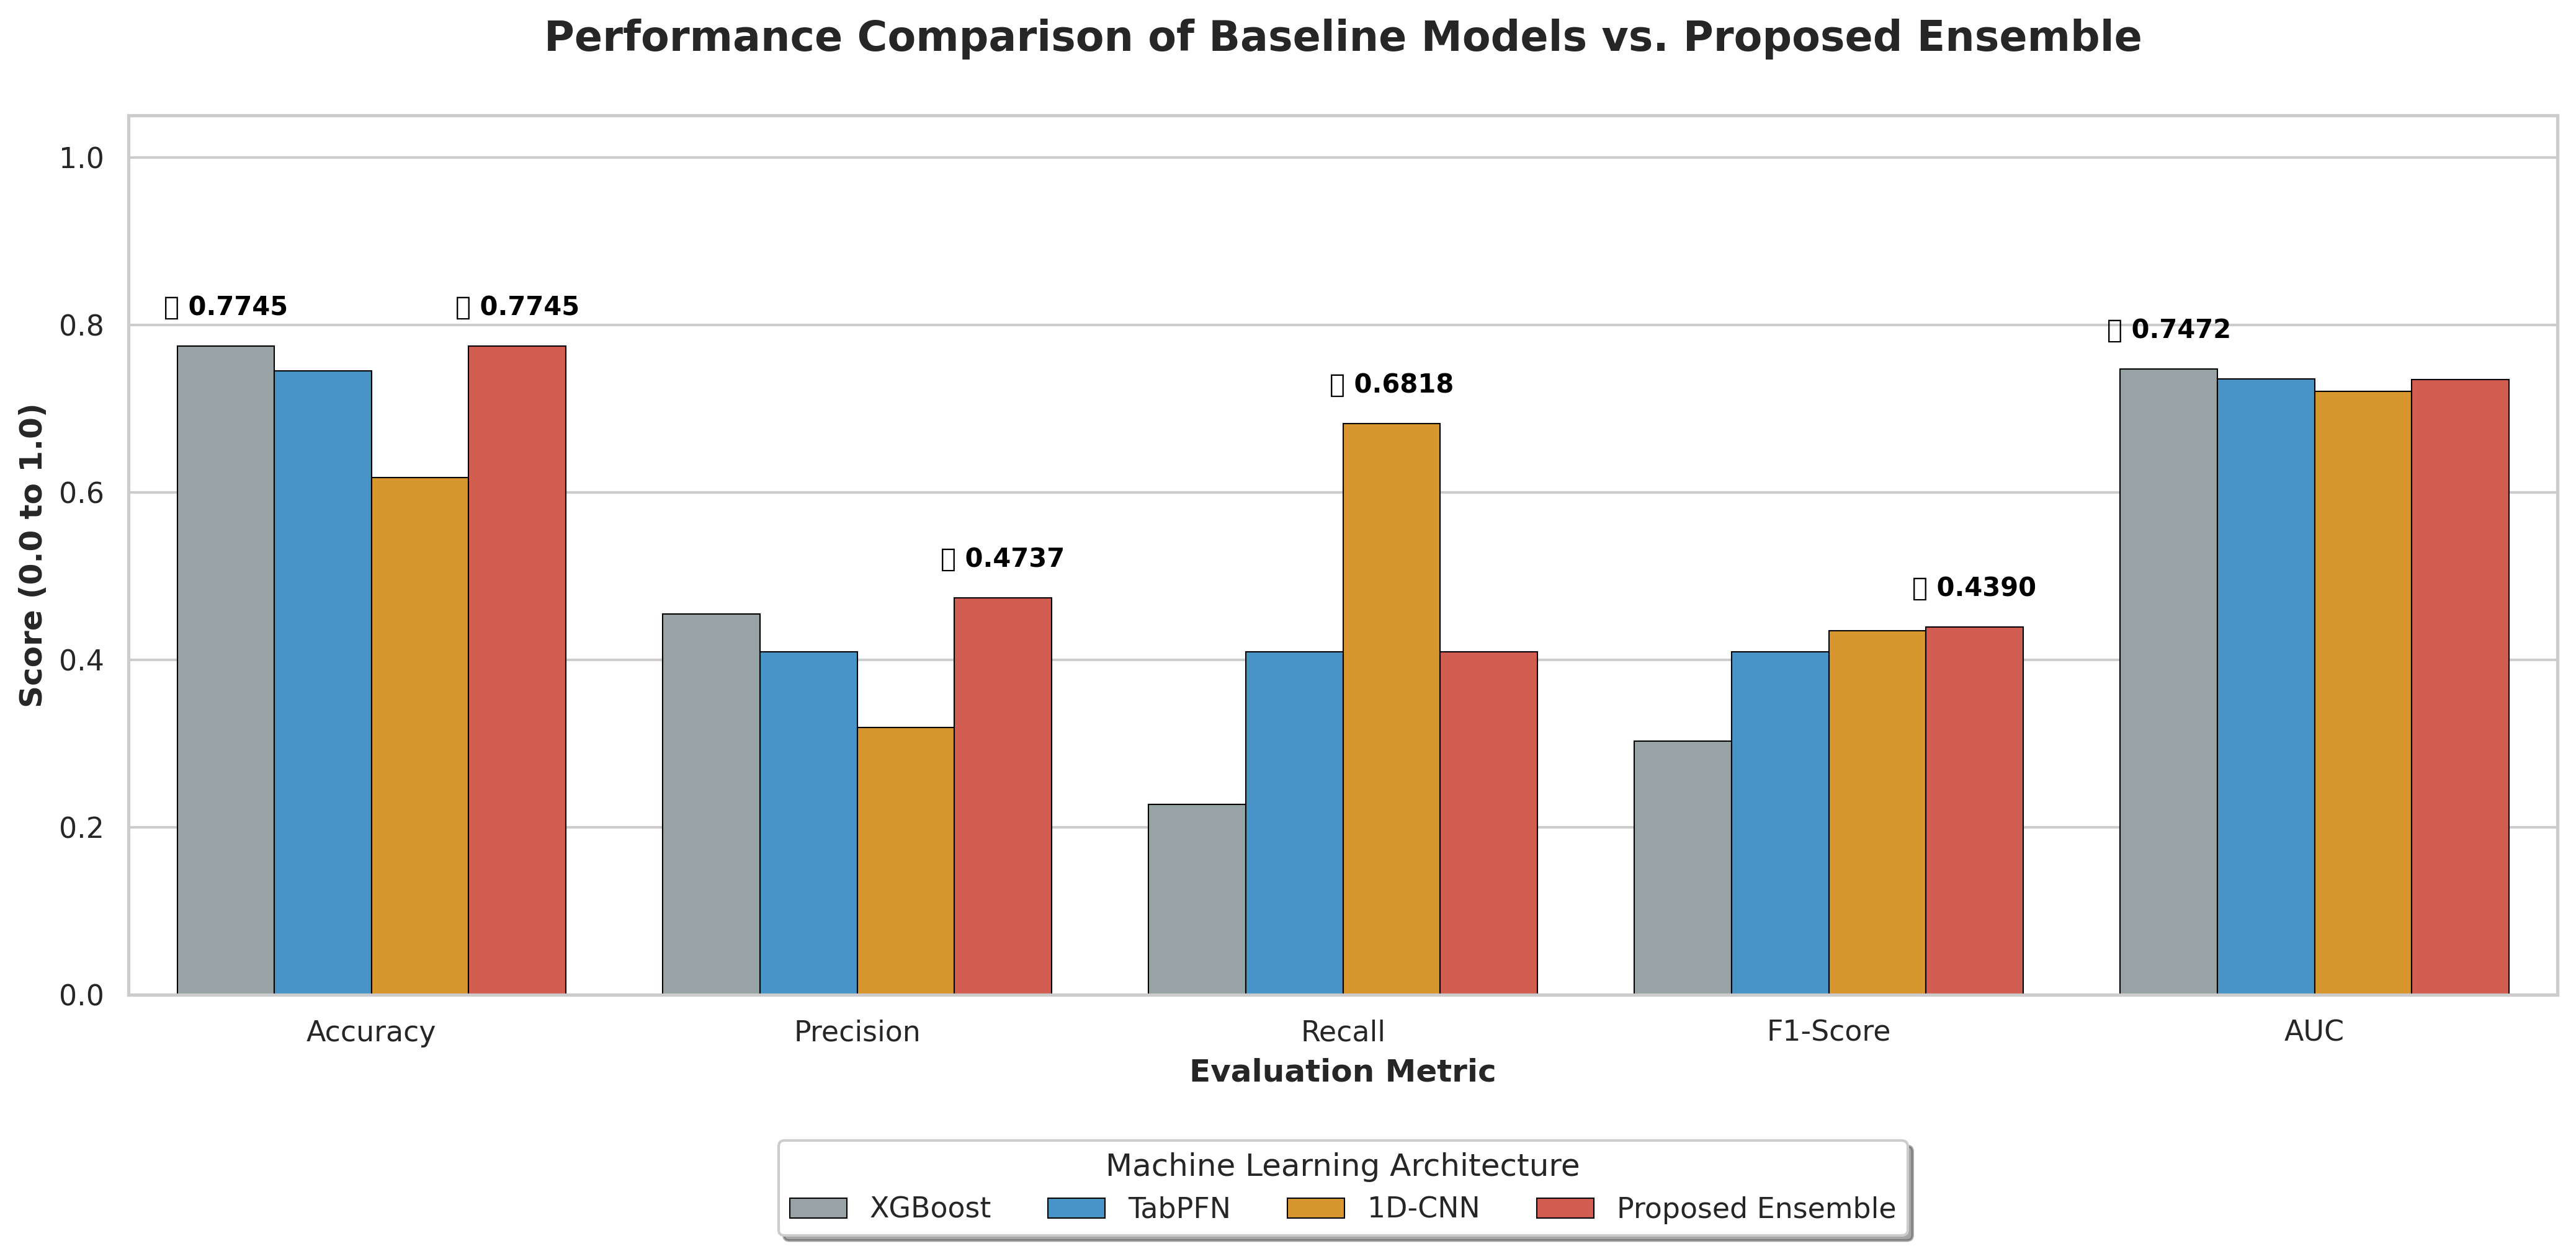

✅ Highlighted chart successfully saved to: /content/drive/MyDrive/Lung_Cancer_Project/experiments/Highlighted_Model_Comparison.png


In [14]:
# ==========================================
# VISUAL 10: HIGHLIGHTED MODEL COMPARISON
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Highlighted Model Comparison Chart...")

# 1. Your exact final benchmark data
data = {
    'Model': ['XGBoost', 'TabPFN', '1D-CNN', 'Proposed Ensemble'],
    'Accuracy': [0.7745, 0.7451, 0.6176, 0.7745],
    'Precision': [0.4545, 0.4091, 0.3191, 0.4737],
    'Recall': [0.2273, 0.4091, 0.6818, 0.4091],
    'F1-Score': [0.3030, 0.4091, 0.4348, 0.4390],
    'AUC': [0.7472, 0.7352, 0.7205, 0.7347]
}

df_bench = pd.DataFrame(data)

# Melt the dataframe for Seaborn
df_melted = df_bench.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 2. Setup the Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Define a professional color palette (making Ensemble stand out slightly)
colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']
ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette=colors, edgecolor='black', linewidth=0.5)

# 3. Automatically Highlight the Best Metric
# Group by Metric to find the maximum score for each category
max_scores = df_melted.groupby('Metric')['Score'].max().to_dict()

# Loop through the bars to add the text
for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue

    # Find which metric this bar belongs to based on its x-coordinate
    # (In seaborn grouped bar charts, the x coordinates cluster around the integer tick marks: 0, 1, 2, 3, 4)
    metric_idx = int(round(p.get_x() + p.get_width()/2))
    metric_name = df_bench.columns[1:][metric_idx]

    # If this bar represents the maximum score for its metric category, highlight it
    if height == max_scores[metric_name]:
        ax.annotate(f'⭐ {height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 15),
                    textcoords = 'offset points',
                    fontweight='bold', color='black', fontsize=10)

# 4. Formatting and Labels
plt.title('Performance Comparison of Baseline Models vs. Proposed Ensemble', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
plt.xlabel('Evaluation Metric', fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Give room for the stars at the top

# Style the legend
plt.legend(title='Machine Learning Architecture', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, frameon=True, shadow=True)

plt.tight_layout()

# 5. Save and Show
plot_path = "/content/drive/MyDrive/Lung_Cancer_Project/experiments/Highlighted_Model_Comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Highlighted chart successfully saved to: {plot_path}")